In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.8 MB/s eta 0:00:00


In [ ]:
# Regular Expression
import re

# Data Analysis and Visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Progress Bar
from tqdm import tqdm

# NLP (Natural Language Processing)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim.downloader as api
from gensim.models import Word2Vec

# Scikit-learn (Classical ML)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report
)

# XGBoost
from xgboost import XGBClassifier

# PyTorch (Deep Learning)
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup
)

# TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Bidirectional,
    Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.regularizers import l2

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 300

Xử lý dữ liệu

In [ ]:
df = pd.read_json('courses_en.json')
df.head()

,url,name,category,what_you_learn,skills,language,instructors,content
0,https://www.coursera.org/learn/-network-security,Network Security,Information Technology,,"Computer Networking, Network Planning And Desi...",English,[~31081695],Welcome to course 4 of 5 of this Specializatio...
1,https://www.coursera.org/learn/-security-princ...,Security Principles,Information Technology,,"Cyber Security Policies, Data Integrity, Cyber...",English,[~31081695],Welcome to course 1 of 5 of this Specializatio...
2,https://www.coursera.org/learn/21st-century-en...,21st Century Energy Transition: how do we make...,Physical Science And Engineering,Understand the complexity of systems supplying...,"Electric Power Systems, Environmental Policy, ...",English,[brad-hayes],NOTE: “21 st Century Energy Transition – How d...
3,https://www.coursera.org/learn/360-vr-video-pr...,VR and 360 Video Production,Arts And Humanities,,"Virtual Reality, Videography, Media Production...",English,[googlearvr],Welcome to the Google AR & VR Virtual Reality ...
4,https://www.coursera.org/learn/3d-anatomy-phys...,Foundations of Human Anatomy and Physiology,Health,Learners will understand how body structure su...,"Vital Signs, Basic Patient Care, Anatomy, Heal...",English,"[~167016541, ~166856472, ~166856442, ~166856230]",This course provides a foundational understand...


In [ ]:
df['text'] = df['what_you_learn'] + ' ' + df['skills'] + ' ' + df['content']

In [ ]:
df['category'].value_counts()

,count
category,
Health,774
Physical Science And Engineering,746
Data Science,660
Information Technology,655
Computer Science,629
Business,548
Social Sciences,507
Arts And Humanities,423
Personal Development,232


In [ ]:
df['label'] = df['category'].map({
    'Arts And Humanities': 0,
    'Business': 1,
    'Computer Science': 2,
    'Data Science': 3,
    'Health': 4,
    'Information Technology': 5,
    'Language Learning': 6,
    'Math And Logic': 7,
    'Personal Development': 8,
    'Physical Science And Engineering': 9,
    'Social Sciences': 10
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5411 entries, 0 to 5410
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             5411 non-null   object
 1   name            5411 non-null   object
 2   category        5411 non-null   object
 3   what_you_learn  5411 non-null   object
 4   skills          5411 non-null   object
 5   language        5411 non-null   object
 6   instructors     5411 non-null   object
 7   content         5411 non-null   object
 8   text            5411 non-null   object
 9   label           5411 non-null   int64 
dtypes: int64(1), object(9)
memory usage: 422.9+ KB


In [ ]:
df[['text', 'label']].head()

,text,label
0,"Computer Networking, Network Planning And Des...",5
1,"Cyber Security Policies, Data Integrity, Cybe...",5
2,Understand the complexity of systems supplying...,9
3,"Virtual Reality, Videography, Media Productio...",0
4,Learners will understand how body structure su...,4


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def preprocess_text(text):

    # Remove HTML tags
    text = re.sub('<[^>]*>', '', text)

    # Remove non-alphabetic characters and convert to lowercase
    text = re.sub('[^a-zA-Z]', ' ', text).lower()

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # Combine words back into a single string
    preprocessed_text = ' '.join(words)

    return preprocessed_text

In [ ]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [ ]:
df[['clean_text', 'label']].head()

,clean_text,label
0,computer networking network planning design tc...,5
1,cyber security policy data integrity cybersecu...,5
2,understand complexity system supplying energy ...,9
3,virtual reality videography medium production ...,0
4,learner understand body structure support func...,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5411 entries, 0 to 5410
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             5411 non-null   object
 1   name            5411 non-null   object
 2   category        5411 non-null   object
 3   what_you_learn  5411 non-null   object
 4   skills          5411 non-null   object
 5   language        5411 non-null   object
 6   instructors     5411 non-null   object
 7   content         5411 non-null   object
 8   text            5411 non-null   object
 9   label           5411 non-null   int64 
 10  clean_text      5411 non-null   object
dtypes: int64(1), object(10)
memory usage: 465.1+ KB


In [ ]:
df['clean_text'].apply(lambda x: len(str(x).split())).mean()

np.float64(166.4939937165034)

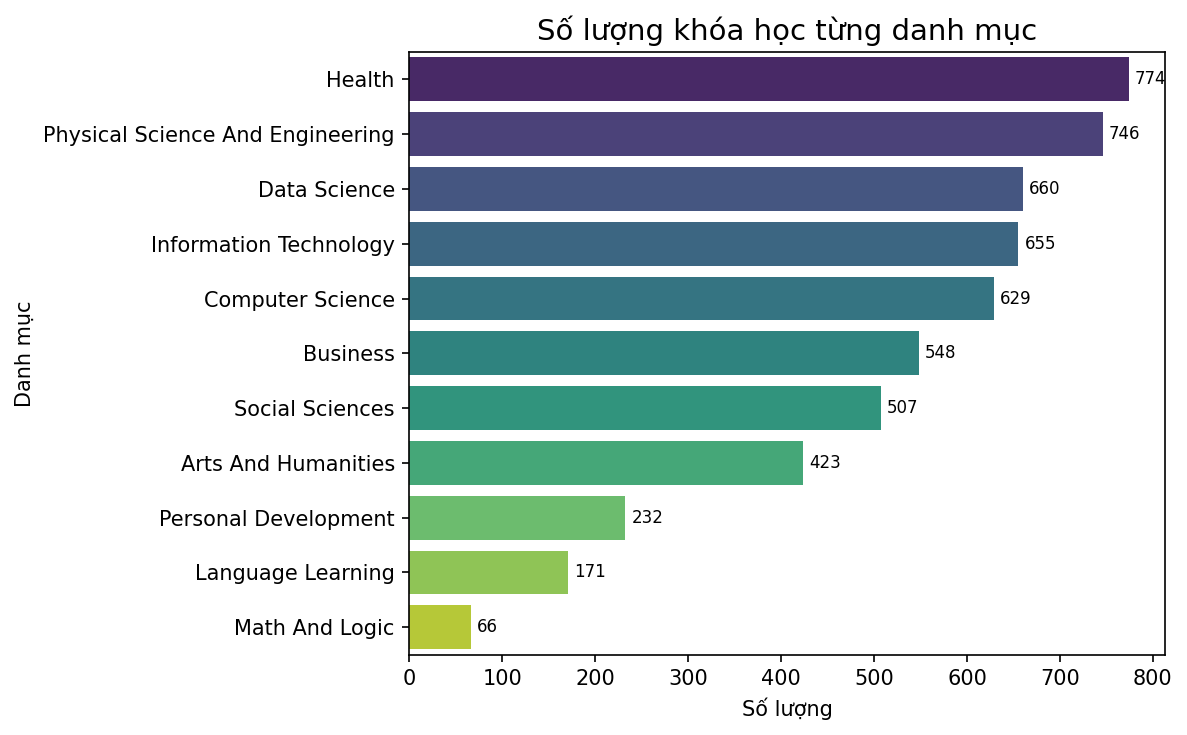

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

order = df['category'].value_counts().index

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, y='category', order=order, palette='viridis')

plt.title('Số lượng khóa học từng danh mục', fontsize=14)
plt.xlabel('Số lượng')
plt.ylabel('Danh mục')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

Using BOW, Tf-IDF, Word2Vec & GloVe with classical machine learning models

In [ ]:
print("Downloading GloVe embeddings...")
glove_vectors = api.load("glove-wiki-gigaword-100")
print(f"Loaded {len(glove_vectors)} word vectors.")

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400000 word vectors.


In [ ]:
def vectorize(text):
    tokens = text.split()
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

def vectorize_with_glove(text):
    tokens = text.split()
    vectors = [glove_vectors[word] for word in tokens if word in glove_vectors]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

# ============================
# Training function
# ============================
def train_model_with_representation(X, y, representation):
    if representation == 'bow':
        vectorizer = CountVectorizer(max_features=8000, ngram_range=(1, 2))
        X_vec = vectorizer.fit_transform(X)
    elif representation == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
        X_vec = vectorizer.fit_transform(X)
    elif representation == 'w2v':
        sentences = [text.split() for text in X]
        global w2v_model
        w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)
        X_vec = np.array([vectorize(t) for t in X])
    elif representation == 'glove':
        global glove_vectors
        X_vec = np.array([vectorize_with_glove(t) for t in X])
    else:
        raise ValueError("Invalid representation type")

    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'),
        "Linear SVM": LinearSVC(),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost": XGBClassifier(objective="multi:softmax", num_class=11, eval_metric="mlogloss", use_label_encoder=False),
        "SGD Classifier": SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
        "Ridge Classifier": RidgeClassifier()
    }

    results = []
    for name, model in tqdm(models.items(), desc=f"Training models ({representation})"):
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")
            recall = recall_score(y_test, y_pred, average="weighted")
            precision = precision_score(y_test, y_pred, average="weighted")

            results.append({
                "Representation": representation,
                "Model": name,
                "Accuracy": acc,
                "F1 Score": f1,
                "Recall": recall,
                "Precision": precision
            })
        except Exception as e:
            print(f"⚠️ {name} failed on {representation}: {e}")
    return pd.DataFrame(results)


# ============================
# Run all representations
# ============================
def compare_all_representations(X, y):
    all_results = pd.DataFrame()

    for rep in ['bow', 'tfidf', 'w2v', 'glove']:
        print(f"\n==================== {rep.upper()} ====================")
        df_result = train_model_with_representation(X, y, rep)
        all_results = pd.concat([all_results, df_result], ignore_index=True)

    summary = all_results.groupby("Representation")[["Accuracy", "F1 Score", "Recall", "Precision"]].mean().reset_index()

    print("\nAverage Performance per Representation:")
    print(summary)

    plt.figure(figsize=(10, 6))
    summary_melted = summary.melt(id_vars="Representation", var_name="Metric", value_name="Score")
    sns.barplot(data=summary_melted, x="Representation", y="Score", hue="Metric", palette="Set2")
    plt.title("Average Model Performance by Representation")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    sns.barplot(data=all_results, x="Model", y="F1 Score", hue="Representation", palette="Set2")
    plt.title("F1 Score Comparison across Models and Representations")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return all_results, summary

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from gensim.models import Word2Vec

# ============================
# Vectorization helpers
# ============================
def vectorize(text):
    tokens = text.split()
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

def vectorize_with_glove(text):
    tokens = text.split()
    vectors = [glove_vectors[word] for word in tokens if word in glove_vectors]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

# ============================
# Training function (fixed)
# ============================
def train_model_with_representation(X, y, representation):
    # 1️⃣ Split data FIRST — to prevent leakage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2️⃣ Vectorization depending on representation
    if representation == 'bow':
        vectorizer = CountVectorizer(max_features=8000, ngram_range=(1, 2))
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

    elif representation == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

    elif representation == 'w2v':
        sentences_train = [text.split() for text in X_train]
        global w2v_model
        w2v_model = Word2Vec(sentences_train, vector_size=100, window=5, min_count=2, workers=4)

        X_train_vec = np.array([vectorize(t) for t in X_train])
        X_test_vec = np.array([vectorize(t) for t in X_test])

    elif representation == 'glove':
        global glove_vectors  # pre-loaded GloVe embeddings
        X_train_vec = np.array([vectorize_with_glove(t) for t in X_train])
        X_test_vec = np.array([vectorize_with_glove(t) for t in X_test])

    else:
        raise ValueError("Invalid representation type")

    # 3️⃣ Define models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'),
        "Linear SVM": LinearSVC(),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost": XGBClassifier(objective="multi:softmax", num_class=len(set(y)), eval_metric="mlogloss", use_label_encoder=False),
        "SGD Classifier": SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
        "Ridge Classifier": RidgeClassifier()
    }

    # 4️⃣ Train + Evaluate
    results = []
    for name, model in tqdm(models.items(), desc=f"Training models ({representation})"):
        try:
            model.fit(X_train_vec, y_train)
            y_pred = model.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")
            recall = recall_score(y_test, y_pred, average="weighted")
            precision = precision_score(y_test, y_pred, average="weighted")

            results.append({
                "Representation": representation,
                "Model": name,
                "Accuracy": acc,
                "F1 Score": f1,
                "Recall": recall,
                "Precision": precision
            })
        except Exception as e:
            print(f"⚠️ {name} failed on {representation}: {e}")

    return pd.DataFrame(results)

# ============================
# Run all representations
# ============================
def compare_all_representations(X, y):
    all_results = pd.DataFrame()

    for rep in ['bow', 'tfidf', 'w2v', 'glove']:
        print(f"\n==================== {rep.upper()} ====================")
        df_result = train_model_with_representation(X, y, rep)
        all_results = pd.concat([all_results, df_result], ignore_index=True)

    summary = all_results.groupby("Representation")[["Accuracy", "F1 Score", "Recall", "Precision"]].mean().reset_index()

    print("\nAverage Performance per Representation:")
    print(summary)

    return all_results, summary

In [ ]:
all_results, summary = compare_all_representations(df['clean_text'], df['label'])


==================== BOW ====================


Training models (bow): 100%|██████████| 6/6 [00:48<00:00,  8.03s/it]



==================== TFIDF ====================


Training models (tfidf): 100%|██████████| 6/6 [02:45<00:00, 27.60s/it]



==================== W2V ====================


Training models (w2v): 100%|██████████| 6/6 [00:27<00:00,  4.50s/it]



==================== GLOVE ====================


Training models (glove): 100%|██████████| 6/6 [00:28<00:00,  4.82s/it]


Average Performance per Representation:
  Representation  Accuracy  F1 Score    Recall  Precision
0            bow  0.736996  0.736849  0.736996   0.740797
1          glove  0.702524  0.702974  0.702524   0.713015
2          tfidf  0.765774  0.765346  0.765774   0.768313
3            w2v  0.711604  0.711791  0.711604   0.718746


In [ ]:
all_results

,Representation,Model,Accuracy,F1 Score,Recall,Precision
0,bow,Logistic Regression,0.755309,0.756476,0.755309,0.759457
1,bow,Linear SVM,0.746999,0.747366,0.746999,0.748529
2,bow,Random Forest,0.761773,0.760602,0.761773,0.769533
3,bow,XGBoost,0.751616,0.749393,0.751616,0.753029
4,bow,SGD Classifier,0.734995,0.735306,0.734995,0.738978
5,bow,Ridge Classifier,0.671283,0.671948,0.671283,0.675258
6,tfidf,Logistic Regression,0.763620,0.763846,0.763620,0.767688
7,tfidf,Linear SVM,0.774700,0.774004,0.774700,0.775121
8,tfidf,Random Forest,0.758079,0.757877,0.758079,0.765061
9,tfidf,XGBoost,0.750693,0.749931,0.750693,0.751706


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def visualize_comparison(all_results, summary):
    sns.set(style="whitegrid", font_scale=1.2)

    # ===== 1️⃣ Biểu đồ trung bình theo phương pháp biểu diễn =====
    plt.figure(figsize=(10, 6))
    summary_melted = summary.melt(id_vars="Representation", var_name="Metric", value_name="Score")
    # đảm bảo không có NaN (nếu muốn hiển thị 0 thì sẽ bị bỏ qua khi annotate vì check height > tol)
    summary_melted = summary_melted.fillna(0)

    ax = sns.barplot(
        data=summary_melted,
        x="Representation",
        y="Score",
        hue="Metric",
        palette="coolwarm",
        edgecolor="black"
    )

    # Annotate: chỉ cho Rectangle có height > tol
    tol = 1e-6
    for p in ax.patches:
        if not isinstance(p, mpatches.Rectangle):
            continue
        height = p.get_height()
        # skip invalid / zero bars
        if height is None:
            continue
        try:
            height_val = float(height)
        except Exception:
            continue
        if np.isfinite(height_val) and height_val > tol:
            ax.annotate(
                f'{height_val:.2f}',
                (p.get_x() + p.get_width() / 2., height_val),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points'
            )

    plt.title("So sánh hiệu suất trung bình theo phương pháp biểu diễn", fontsize=14, weight='bold')
    plt.ylim(0, 1)
    plt.ylabel("Điểm trung bình")
    plt.xlabel("Phương pháp biểu diễn")
    plt.legend(title="Chỉ số đánh giá", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # ===== 2️⃣ So sánh F1 Score giữa các mô hình và biểu diễn =====
    plt.figure(figsize=(14, 7))
    ax = sns.barplot(
        data=all_results,
        x="Model",
        y="F1 Score",
        hue="Representation",
        palette="crest",
        edgecolor="black"
    )

    # Annotate (cùng logic)
    for p in ax.patches:
        if not isinstance(p, mpatches.Rectangle):
            continue
        height = p.get_height()
        if height is None:
            continue
        try:
            height_val = float(height)
        except Exception:
            continue
        if np.isfinite(height_val) and height_val > tol:
            ax.annotate(
                f'{height_val:.2f}',
                (p.get_x() + p.get_width() / 2., height_val),
                ha='center', va='bottom',
                fontsize=9, color='black', xytext=(0, 4),
                textcoords='offset points'
            )

    plt.title("So sánh F1-score giữa các mô hình trong từng nhóm biểu diễn", fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.ylabel("F1 Score")
    plt.xlabel("Tên mô hình")
    plt.legend(title="Phương pháp biểu diễn", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # ===== 3️⃣ Heatmap tổng hợp =====
    pivot_table = all_results.pivot_table(
        index="Model", columns="Representation", values="F1 Score", aggfunc="mean"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot_table,
        annot=True, fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={'label': 'F1 Score trung bình'}
    )
    plt.title("Heatmap so sánh F1 Score giữa mô hình và biểu diễn", fontsize=14, weight='bold')
    plt.ylabel("Mô hình")
    plt.xlabel("Phương pháp biểu diễn")
    plt.tight_layout()
    plt.show()


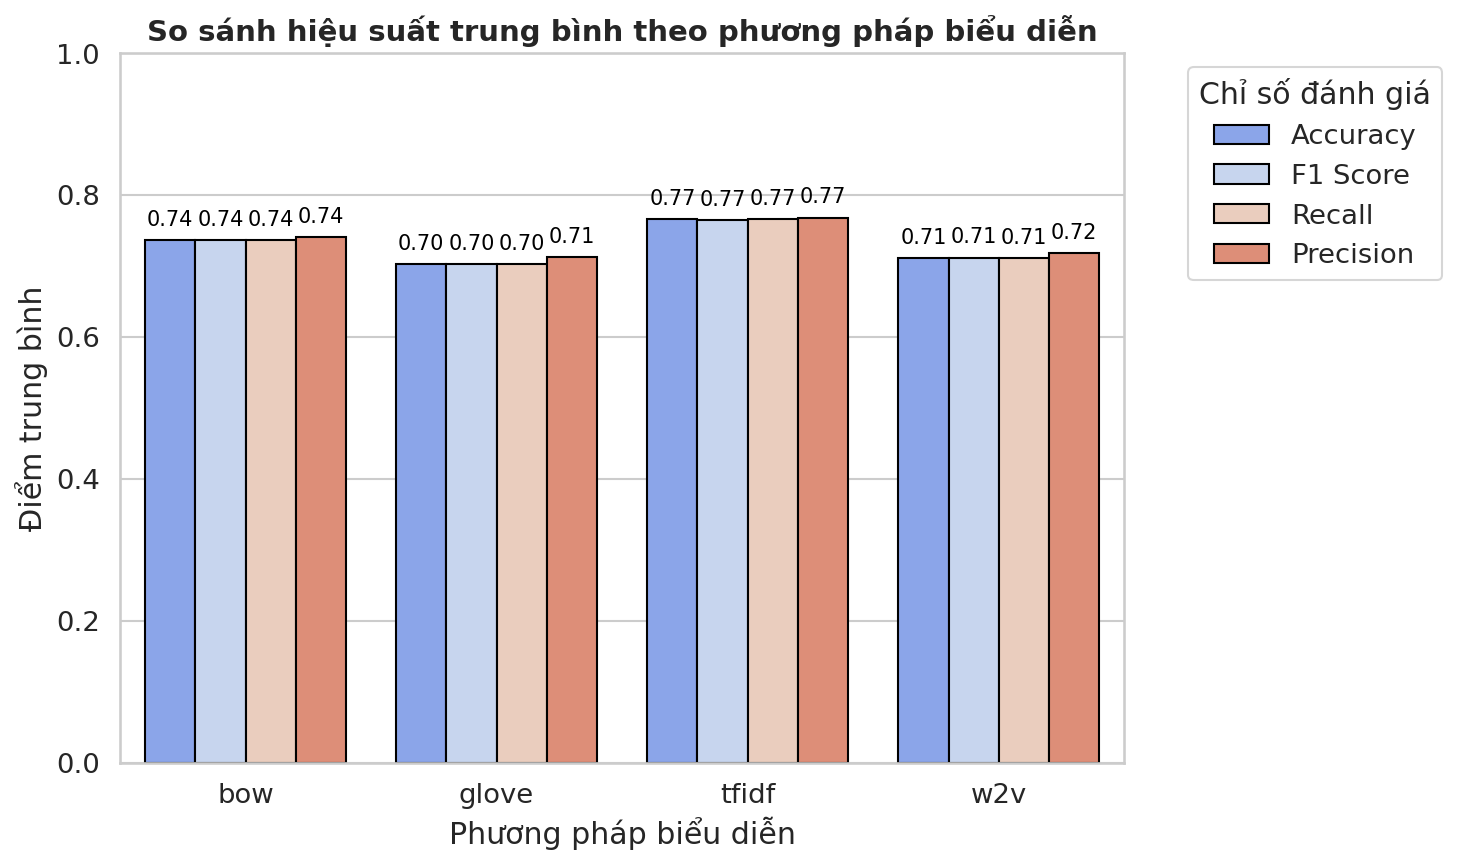

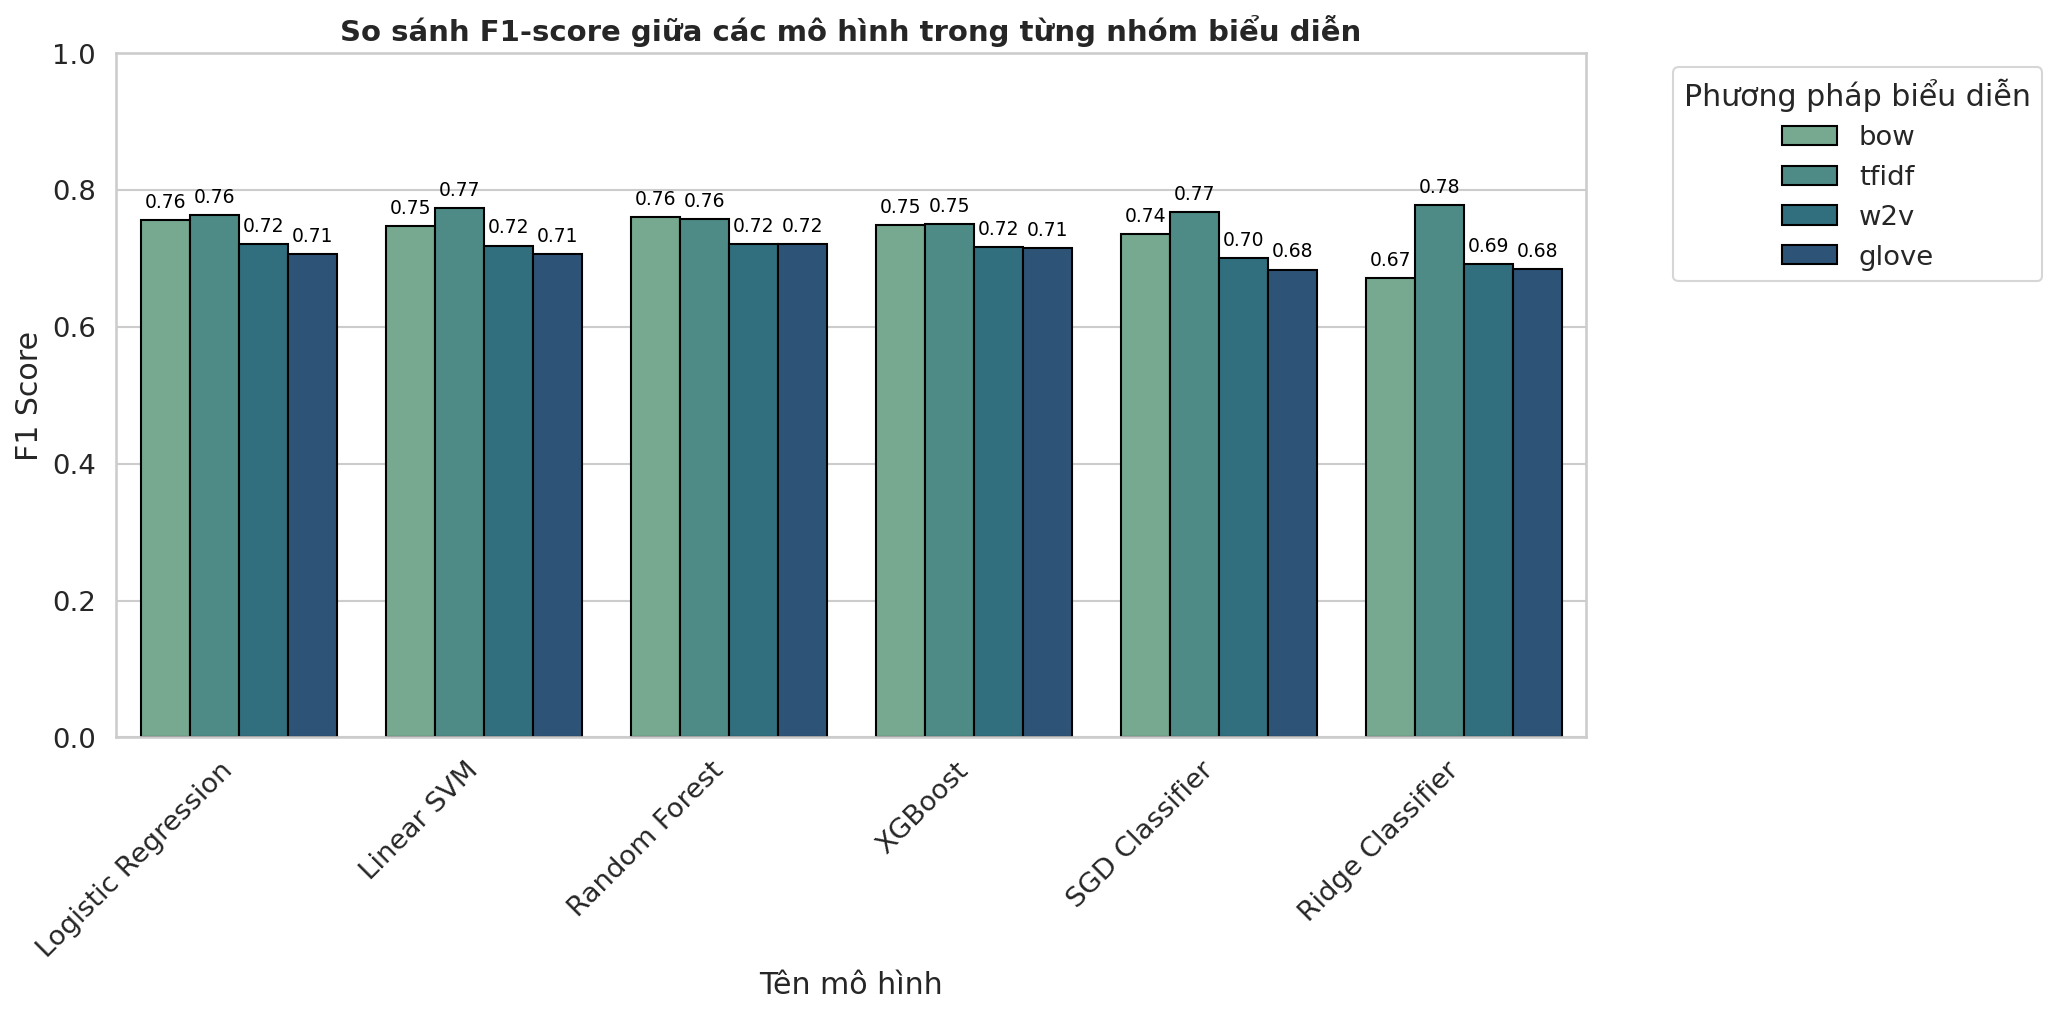

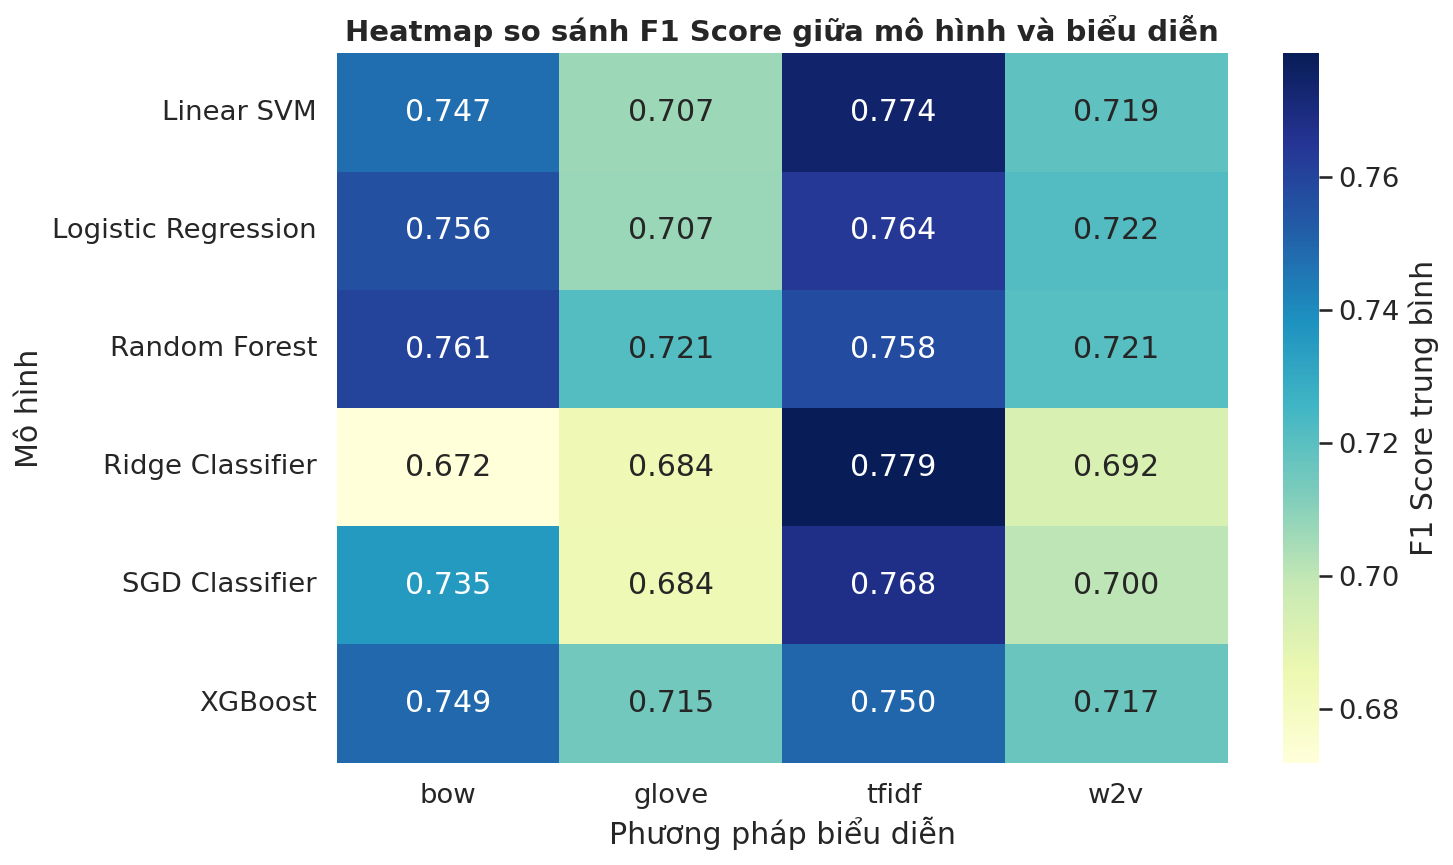

In [ ]:
visualize_comparison(all_results, summary)

🔹 1/25 | CV Acc: 0.7777 | alpha=3.845
🔹 2/25 | CV Acc: 0.7914 | alpha=1.660
🔹 3/25 | CV Acc: 0.7830 | alpha=1.529
🔹 4/25 | CV Acc: 0.7743 | alpha=0.108
🔹 5/25 | CV Acc: 0.7729 | alpha=0.171
🔹 6/25 | CV Acc: 0.7775 | alpha=0.567
🔹 7/25 | CV Acc: 0.7733 | alpha=6.284
🔹 8/25 | CV Acc: 0.7752 | alpha=6.903
🔹 9/25 | CV Acc: 0.7768 | alpha=5.733
🔹 10/25 | CV Acc: 0.7787 | alpha=2.510
🔹 11/25 | CV Acc: 0.7706 | alpha=9.193
🔹 12/25 | CV Acc: 0.7810 | alpha=5.567
🔹 13/25 | CV Acc: 0.7736 | alpha=9.495
🔹 14/25 | CV Acc: 0.7798 | alpha=5.804
🔹 15/25 | CV Acc: 0.7715 | alpha=7.573
🔹 16/25 | CV Acc: 0.7817 | alpha=3.063
🔹 17/25 | CV Acc: 0.7796 | alpha=3.035
🔹 18/25 | CV Acc: 0.7715 | alpha=7.813
🔹 19/25 | CV Acc: 0.7761 | alpha=6.333
🔹 20/25 | CV Acc: 0.7726 | alpha=6.759
🔹 21/25 | CV Acc: 0.7807 | alpha=1.296
🔹 22/25 | CV Acc: 0.7720 | alpha=7.810
🔹 23/25 | CV Acc: 0.7791 | alpha=0.354
🔹 24/25 | CV Acc: 0.7798 | alpha=3.244
🔹 25/25 | CV Acc: 0.7925 | alpha=1.000

✅ Best Parameters:
{'tfidf__max_f

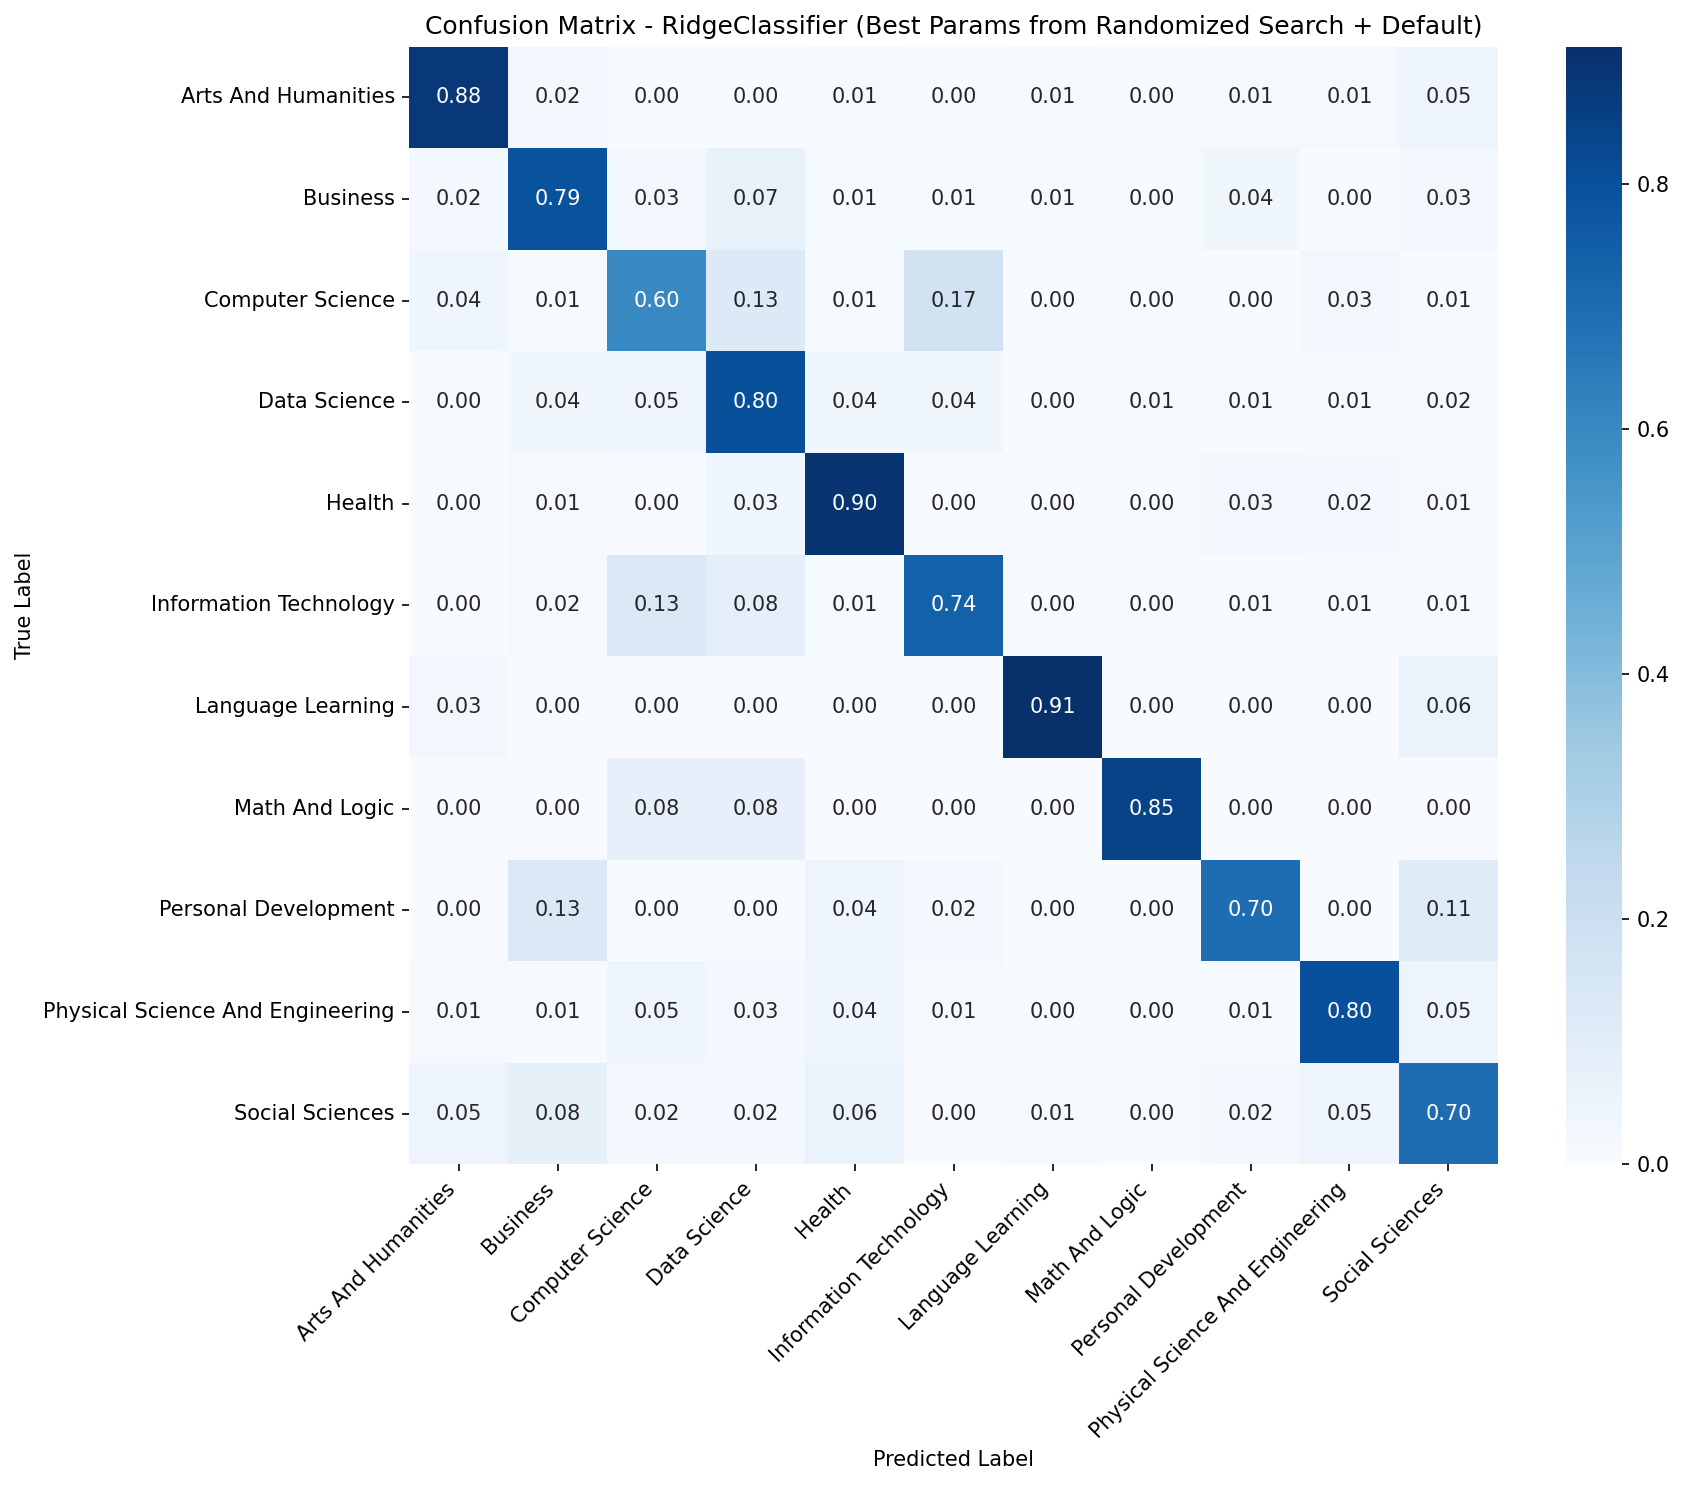

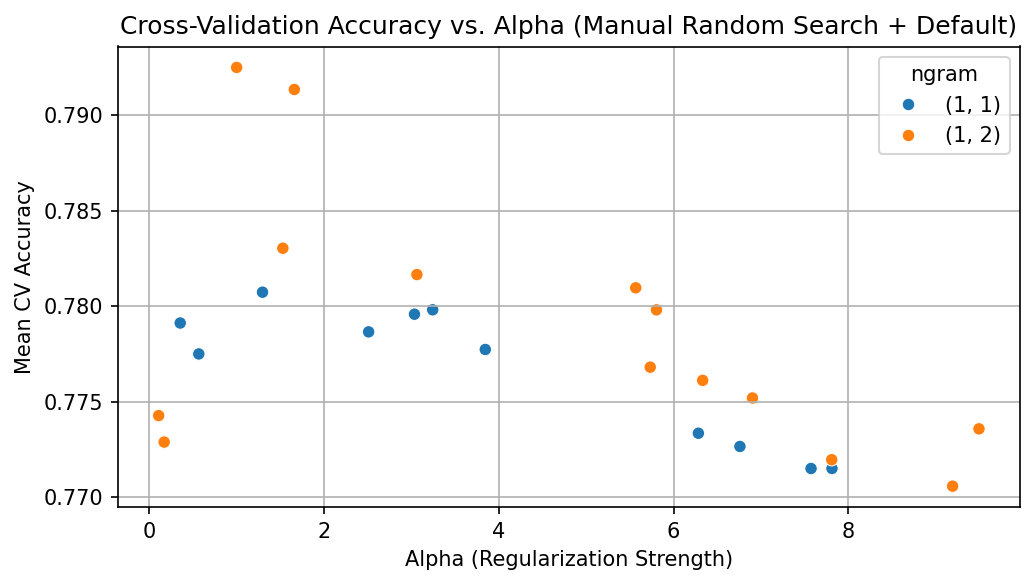

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import uniform, randint

# --- Chuẩn bị dữ liệu ---
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Không gian siêu tham số ---
param_distributions = {
    'tfidf__max_features': randint(3000, 10000),
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'clf__alpha': uniform(0.1, 10.0),
    'clf__solver': ['auto', 'lsqr', 'sparse_cg', 'sag'],
    'clf__tol': [1e-3, 1e-4],
}

# --- Thêm tham số mặc định ---
default_params = {
    'tfidf__max_features': 8000,
    'tfidf__ngram_range': (1,2),
    'tfidf__min_df': 1,
    'tfidf__max_df': 1.0,
    'clf__alpha': 1.0,
    'clf__solver': 'auto',
    'clf__tol': 1e-4,
}

# --- Sinh 24 tổ hợp ngẫu nhiên + thêm mặc định ---
random_params = list(ParameterSampler(param_distributions, n_iter=24, random_state=42))
random_params.append(default_params)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --- Tìm kiếm thủ công (tương tự RandomizedSearchCV) ---
results = []

for i, params in enumerate(random_params, start=1):
    model = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=params['tfidf__max_features'],
            ngram_range=params['tfidf__ngram_range'],
            min_df=params['tfidf__min_df'],
            max_df=params['tfidf__max_df']
        )),
        ('clf', RidgeClassifier(
            alpha=params['clf__alpha'],
            solver=params['clf__solver'],
            tol=params['clf__tol'],
            random_state=42
        ))
    ])

    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        score = model.score(X_train.iloc[val_idx], y_train.iloc[val_idx])
        scores.append(score)

    mean_score = np.mean(scores)
    results.append((params, mean_score))
    print(f"🔹 {i}/{len(random_params)} | CV Acc: {mean_score:.4f} | alpha={params['clf__alpha']:.3f}")

# --- Chọn bộ tham số tốt nhất ---
best_params, best_score = max(results, key=lambda x: x[1])
print("\n✅ Best Parameters:")
print(best_params)
print(f"✅ Best Cross-Validation Accuracy: {best_score:.4f}")

# --- Huấn luyện lại mô hình tốt nhất trên toàn bộ train ---
best_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_params['tfidf__max_features'],
        ngram_range=best_params['tfidf__ngram_range'],
        min_df=best_params['tfidf__min_df'],
        max_df=best_params['tfidf__max_df']
    )),
    ('clf', RidgeClassifier(
        alpha=best_params['clf__alpha'],
        solver=best_params['clf__solver'],
        tol=best_params['clf__tol'],
        random_state=42
    ))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# --- Báo cáo ---
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

test_acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {test_acc:.4f}")

# --- Ma trận nhầm lẫn ---
cm = confusion_matrix(y_test, y_pred, normalize='true')

label_map = {
    0: 'Arts And Humanities',
    1: 'Business',
    2: 'Computer Science',
    3: 'Data Science',
    4: 'Health',
    5: 'Information Technology',
    6: 'Language Learning',
    7: 'Math And Logic',
    8: 'Personal Development',
    9: 'Physical Science And Engineering',
    10: 'Social Sciences'
}

labels = [label_map[i] for i in range(len(label_map))]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - RidgeClassifier (Best Params from Randomized Search + Default)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Biểu đồ alpha vs accuracy ---
results_df = pd.DataFrame([
    {'alpha': p['clf__alpha'], 'cv_acc': s, 'ngram': p['tfidf__ngram_range']}
    for p, s in results
])

plt.figure(figsize=(7, 4))
sns.scatterplot(x='alpha', y='cv_acc', data=results_df, hue='ngram')
plt.title("Cross-Validation Accuracy vs. Alpha (Manual Random Search + Default)")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import random
import nltk
from nltk.corpus import wordnet
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# ===============================
# 1️⃣ Chuẩn bị dữ liệu
# ===============================
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df_train = pd.DataFrame({'clean_text': X_train, 'label': y_train})
print("🔍 Phân bố nhãn ban đầu:")
print(df_train['label'].value_counts().sort_index())

# ===============================
# 2️⃣ Hàm tăng cường EDA
# ===============================
nltk.download('wordnet')
nltk.download('omw-1.4')

def synonym_replacement(words, n):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

def random_insertion(words, n):
    new_words = words.copy()
    for _ in range(n):
        add_word = random.choice(words)
        new_words.insert(random.randint(0, len(new_words)), add_word)
    return new_words

def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            return new_words
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = [word for word in words if random.uniform(0, 1) > p]
    return new_words if new_words else [random.choice(words)]

def eda(sentence, alpha_sr=0.1, alpha_ri=0.1, alpha_rs=0.1, p_rd=0.1, num_aug=1):
    words = sentence.split()
    num_words = len(words)
    augmented_sentences = []
    for _ in range(num_aug):
        a_words = words.copy()
        a_words = synonym_replacement(a_words, max(1, int(alpha_sr * num_words)))
        a_words = random_insertion(a_words, max(1, int(alpha_ri * num_words)))
        a_words = random_swap(a_words, max(1, int(alpha_rs * num_words)))
        a_words = random_deletion(a_words, p_rd)
        augmented_sentences.append(' '.join(a_words))
    return augmented_sentences

# ===============================
# 3️⃣ Tăng cường dữ liệu
# ===============================
max_count = df_train['label'].value_counts().max()
augmented_texts = []

for label, group in df_train.groupby('label'):
    n_to_augment = max_count - len(group)
    if n_to_augment > 0:
        print(f"\n✳️ Tăng cường lớp {label} thêm {n_to_augment} mẫu...")
        sampled_texts = resample(
            group['clean_text'], replace=True,
            n_samples=n_to_augment, random_state=42
        )
        new_texts = []
        for text in tqdm(sampled_texts, desc=f"Class {label}", leave=False):
            try:
                aug_texts = eda(text, 0.05, 0.05, 0.05, 0.05, num_aug=1)
                new_texts.extend(aug_texts)
            except Exception:
                continue
        augmented_texts.extend(zip(new_texts, [label] * len(new_texts)))

df_aug = pd.DataFrame(augmented_texts, columns=['clean_text', 'label'])
df_train_aug = pd.concat([df_train, df_aug]).reset_index(drop=True)

print("\n✅ Sau tăng cường EDA, phân bố nhãn:")
print(df_train_aug['label'].value_counts().sort_index())

# ===============================
# 4️⃣ Mô hình RidgeClassifier với tham số tối ưu
# ===============================
best_params = {
    'tfidf__max_features': 8000,
    'tfidf__ngram_range': (1, 2),
    'tfidf__min_df': 1,
    'tfidf__max_df': 1.0,
    'clf__alpha': 1.0,
    'clf__solver': 'auto',
    'clf__tol': 0.0001
 }

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_params['tfidf__max_features'],
        ngram_range=best_params['tfidf__ngram_range'],
        min_df=best_params['tfidf__min_df'],
        max_df=best_params['tfidf__max_df']
    )),
    ('clf', RidgeClassifier(
        alpha=best_params['clf__alpha'],
        solver=best_params['clf__solver'],
        tol=best_params['clf__tol'],
        random_state=42
    ))
])

# Huấn luyện mô hình gốc và mô hình sau EDA
print("\n🧠 Training original Ridge model...")
pipeline.fit(df_train['clean_text'], df_train['label'])
y_pred_orig = pipeline.predict(X_test)

print("🧠 Training augmented Ridge model...")
pipeline.fit(df_train_aug['clean_text'], df_train_aug['label'])
y_pred_aug = pipeline.predict(X_test)

# ===============================
# 5️⃣ So sánh hiệu suất
# ===============================
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (macro)": recall_score(y_true, y_pred, average='macro'),
        "F1-score (macro)": f1_score(y_true, y_pred, average='macro')
    }

metrics_orig = compute_metrics(y_test, y_pred_orig)
metrics_aug = compute_metrics(y_test, y_pred_aug)

comparison_df = pd.DataFrame([metrics_orig, metrics_aug], index=["Original", "EDA-Augmented"])
print("\n⚖️ So sánh hiệu suất RidgeClassifier (Best Params):")
print(comparison_df.round(4))

# ===============================
# 6️⃣ Báo cáo chi tiết
# ===============================
print("\n📘 Báo cáo chi tiết (Mô hình gốc):")
print(classification_report(y_test, y_pred_orig, digits=4))

print("\n📗 Báo cáo chi tiết (Mô hình EDA-Augmented):")
print(classification_report(y_test, y_pred_aug, digits=4))

🔍 Phân bố nhãn ban đầu:
label
0     338
1     438
2     503
3     528
4     619
5     524
6     137
7      53
8     186
9     597
10    405
Name: count, dtype: int64


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



✳️ Tăng cường lớp 0 thêm 281 mẫu...



✳️ Tăng cường lớp 1 thêm 181 mẫu...



✳️ Tăng cường lớp 2 thêm 116 mẫu...


...


✳️ Tăng cường lớp 7 thêm 566 mẫu...



✳️ Tăng cường lớp 8 thêm 433 mẫu...



✳️ Tăng cường lớp 9 thêm 22 mẫu...



✳️ Tăng cường lớp 10 thêm 214 mẫu...



✅ Sau tăng cường EDA, phân bố nhãn:
label
0     619
1     619
2     619
3     619
4     619
5     619
6     619
7     619
8     619
9     619
10    619
Name: count, dtype: int64

🧠 Training original Ridge model...
🧠 Training augmented Ridge model...

⚖️ So sánh hiệu suất RidgeClassifier (Best Params):
               Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Original         0.7793             0.7928          0.7877            0.7892
EDA-Augmented    0.7701             0.7691          0.7975            0.7805

📘 Báo cáo chi tiết (Mô hình gốc):
              precision    recall  f1-score   support

           0     0.8333    0.8824    0.8571        85
           1     0.7632    0.7909    0.7768       110
           2     0.6786    0.6032    0.6387       126
           3     0.6928    0.8030    0.7439       132
           4     0.8580    0.8968    0.8770       155
           5     0.7578    0.7405    0.7490       131
           6     0.9118    0.9118    0.9118        

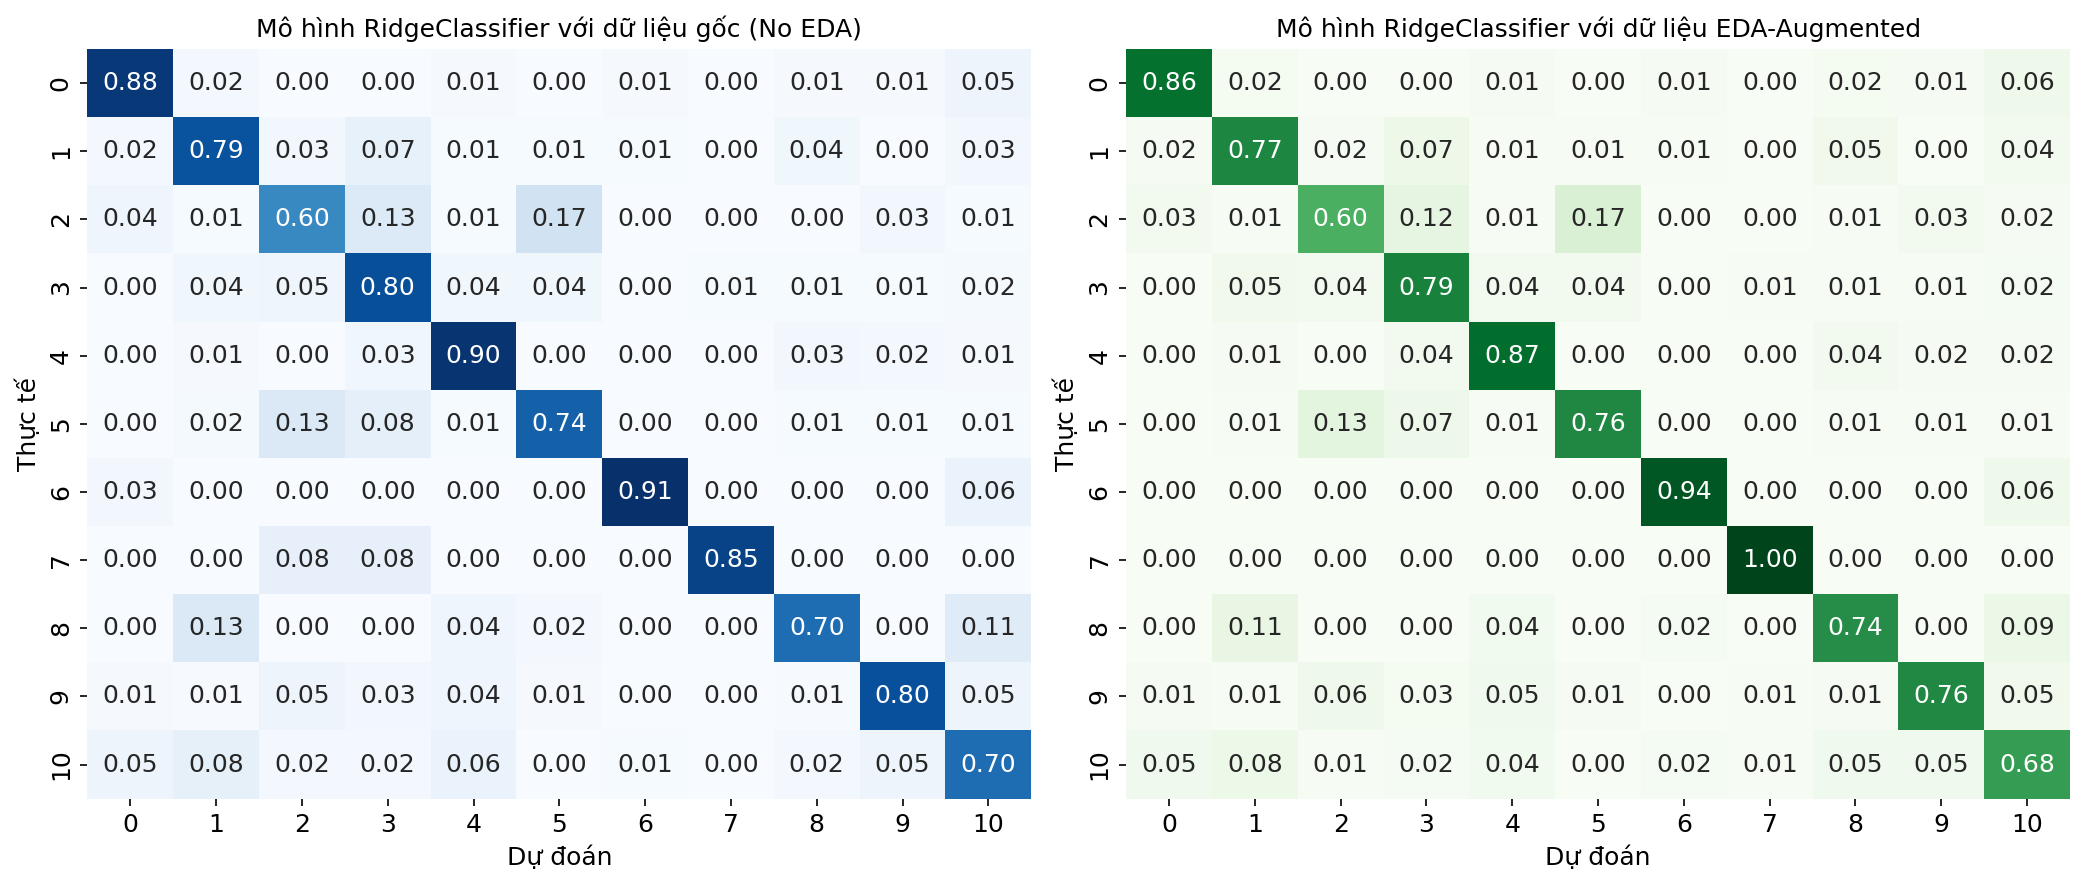

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🎯 Confusion Matrix (chuẩn hóa theo hàng)
cm_orig = confusion_matrix(y_test, y_pred_orig, normalize='true')
cm_aug = confusion_matrix(y_test, y_pred_aug, normalize='true')

# 🧩 Vẽ song song hai biểu đồ (không có nhãn)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm_orig, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0],
    annot_kws={"size": 12}
)
axes[0].set_title("Mô hình RidgeClassifier với dữ liệu gốc (No EDA)", fontsize=12)
axes[0].set_xlabel("Dự đoán", fontsize=12)
axes[0].set_ylabel("Thực tế", fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)

sns.heatmap(
    cm_aug, annot=True, fmt=".2f", cmap="Greens", cbar=False, ax=axes[1],
    annot_kws={"size": 12}
)
axes[1].set_title("Mô hình RidgeClassifier với dữ liệu EDA-Augmented", fontsize=12)
axes[1].set_xlabel("Dự đoán", fontsize=12)
axes[1].set_ylabel("Thực tế", fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

### RNN models

In [ ]:
import random
import nltk
from nltk.corpus import wordnet
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Attention, LayerNormalization

# ============================================
# Chuẩn bị dữ liệu & tải WordNet
# ============================================
nltk.download('wordnet')
nltk.download('omw-1.4')

# Giả sử bạn đã có DataFrame df với các cột: clean_text, label
# df = pd.read_csv("courses_clean.csv")

num_classes = df['label'].nunique()
print("Số lớp:", num_classes)

# ============================================
# Các hàm EDA cơ bản
# ============================================
def synonym_replacement(words, n):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

def random_insertion(words, n):
    new_words = words.copy()
    for _ in range(n):
        add_word = random.choice(words)
        new_words.insert(random.randint(0, len(new_words)), add_word)
    return new_words

def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            return new_words
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = [word for word in words if random.uniform(0, 1) > p]
    return new_words if new_words else [random.choice(words)]

def eda(sentence, alpha_sr=0.1, alpha_ri=0.1, alpha_rs=0.1, p_rd=0.1, num_aug=1):
    words = sentence.split()
    num_words = len(words)
    augmented_sentences = []
    for _ in range(num_aug):
        a_words = words.copy()
        a_words = synonym_replacement(a_words, max(1, int(alpha_sr * num_words)))
        a_words = random_insertion(a_words, max(1, int(alpha_ri * num_words)))
        a_words = random_swap(a_words, max(1, int(alpha_rs * num_words)))
        a_words = random_deletion(a_words, p_rd)
        augmented_sentences.append(' '.join(a_words))
    return augmented_sentences

# ============================================
# Chia dữ liệu train / val / test & tăng cường
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_train, df_val = train_test_split(df_train, test_size=0.125, random_state=42, stratify=df_train['label'])

print(f"Tập train: {len(df_train)}, val: {len(df_val)}, test: {len(df_test)}")

# === EDA augmentation chỉ trên train ===
max_count = df_train['label'].value_counts().max()
augmented_texts = []

for label, group in df_train.groupby('label'):
    n_to_augment = max_count - len(group)
    if n_to_augment > 0:
        sampled_texts = resample(
            group['clean_text'],
            replace=True,
            n_samples=n_to_augment,
            random_state=42
        )
        new_texts = []
        for text in sampled_texts:
            try:
                aug_texts = eda(text, num_aug=4)
                new_texts.extend(aug_texts)
            except Exception:
                continue
        augmented_texts.extend(zip(new_texts, [label] * len(new_texts)))

df_aug = pd.DataFrame(augmented_texts, columns=['clean_text', 'label'])
df_train_aug = pd.concat([df_train, df_aug]).reset_index(drop=True)

print("\nTrước EDA:\n", df_train['label'].value_counts())
print("\nSau EDA:\n", df_train_aug['label'].value_counts())

# ============================================
# Tokenize & Pad sequences
# ============================================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text'])

def prepare_data(df):
    seq = tokenizer.texts_to_sequences(df['clean_text'])
    X = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    y = to_categorical(df['label'], num_classes=num_classes)
    return X, y

X_train, y_train = prepare_data(df_train)
X_train_aug, y_train_aug = prepare_data(df_train_aug)
X_val, y_val = prepare_data(df_val)
X_test, y_test = prepare_data(df_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ============================================
# Xây dựng lớp Attention tuỳ chỉnh
# ============================================
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
import tensorflow as tf

class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# ============================================
# Kiến trúc LSTM + Attention (Sequential)
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization

def build_lstm_attention():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)),
        Attention(),
        LayerNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ============================================
# Huấn luyện hai mô hình
# ============================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

model_orig = build_lstm_attention()
model_aug = build_lstm_attention()

history_orig = model_orig.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Số lớp: 11
Tập train: 3787, val: 541, test: 1083

Trước EDA:
 label
4     542
9     522
3     462
5     459
2     440
1     383
10    354
0     296
8     163
6     120
7      46
Name: count, dtype: int64

Sau EDA:
 label
7     2030
6     1808
8     1679
0     1280
10    1106
1     1019
2      848
5      791
3      782
9      602
4      542
Name: count, dtype: int64
Train: (3787, 200), Val: (541, 200), Test: (1083, 200)
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.1235 - loss: 2.4721 - val_accuracy: 0.4806 - val_loss: 1.8934 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.3647 - loss: 1.8841 - val_accuracy: 0.6839 - val_loss: 1.1833 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5628 - loss: 1.3538 - val_accuracy: 0.6950 - val_loss: 1.0016 - learning_rate: 0.0010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6687 - loss: 1.0523 - val_accuracy: 0.7301 - val_loss: 0.8825 -


🎯 Mô hình gốc — Accuracy: 0.7331, Loss: 0.8780
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step
              precision    recall  f1-score   support

           0     0.7188    0.8118    0.7624        85
           1     0.7407    0.7273    0.7339       110
           2     0.6842    0.6190    0.6500       126
           3     0.6824    0.7652    0.7214       132
           4     0.8767    0.8258    0.8505       155
           5     0.7559    0.7328    0.7442       131
           6     0.6042    0.8529    0.7073        34
           7     0.0000    0.0000    0.0000        13
           8     0.7059    0.2609    0.3810        46
           9     0.8141    0.8523    0.8328       149
          10     0.6016    0.7255    0.6578       102

    accuracy                         0.7331      1083
   macro avg     0.6531    0.6521    0.6401      1083
weighted avg     0.7290    0.7331    0.7246      1083


🎯 Mô hình EDA-Augmented — Accuracy: 0.7304, Loss: 0.9147
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/ste

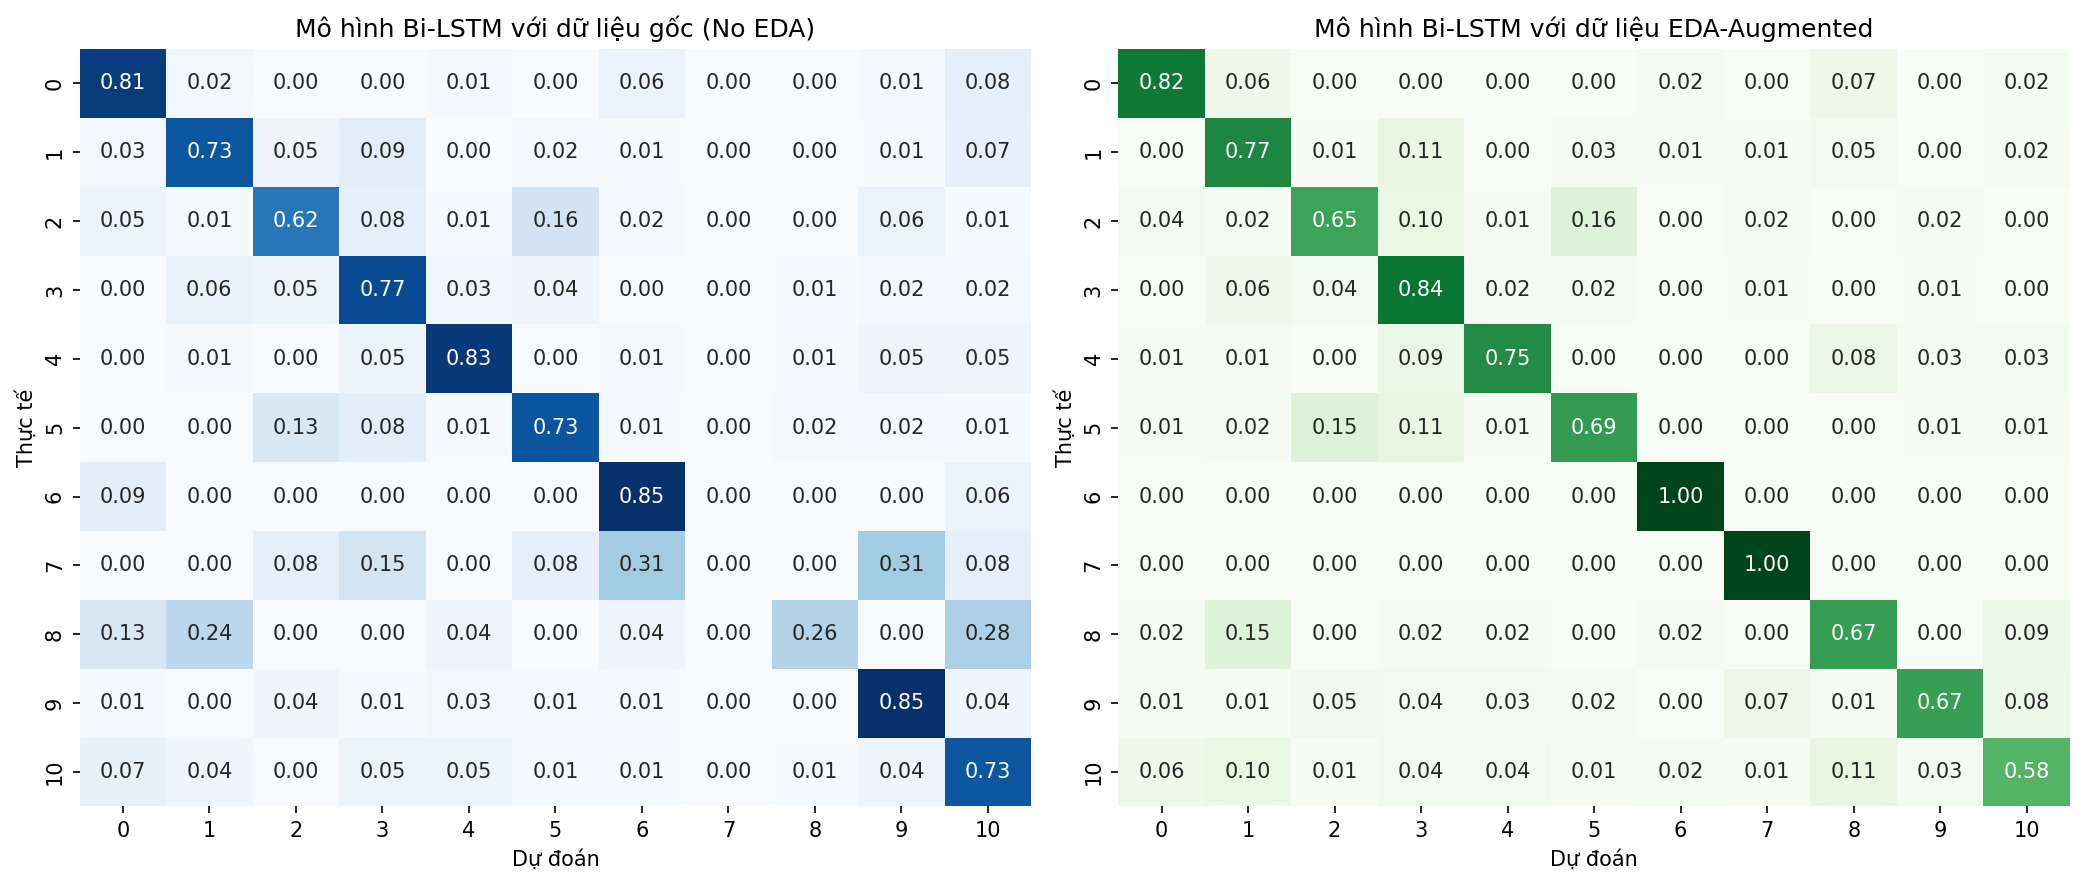

In [ ]:
# ============================================
# Đánh giá mô hình
# ============================================
def evaluate_model(model, name):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n🎯 {name} — Accuracy: {acc:.4f}, Loss: {loss:.4f}")
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    print(classification_report(y_true, y_pred, digits=4))
    return y_true, y_pred

y_true_orig, y_pred_orig = evaluate_model(model_orig, "Mô hình gốc")
y_true_aug, y_pred_aug = evaluate_model(model_aug, "Mô hình EDA-Augmented")

# ============================================
# Vẽ Confusion Matrix (theo %)
# ============================================
labels_sorted = sorted(df['label'].unique())

cm_orig = confusion_matrix(y_true_orig, y_pred_orig, labels=labels_sorted, normalize='true')
cm_aug = confusion_matrix(y_true_aug, y_pred_aug, labels=labels_sorted, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_orig, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
axes[0].set_title("Mô hình Bi-LSTM với dữ liệu gốc (No EDA)")
axes[0].set_xlabel("Dự đoán")
axes[0].set_ylabel("Thực tế")

sns.heatmap(cm_aug, annot=True, fmt=".2f", cmap="Greens", cbar=False,
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
axes[1].set_title("Mô hình Bi-LSTM với dữ liệu EDA-Augmented")
axes[1].set_xlabel("Dự đoán")
axes[1].set_ylabel("Thực tế")

plt.tight_layout()
plt.show()

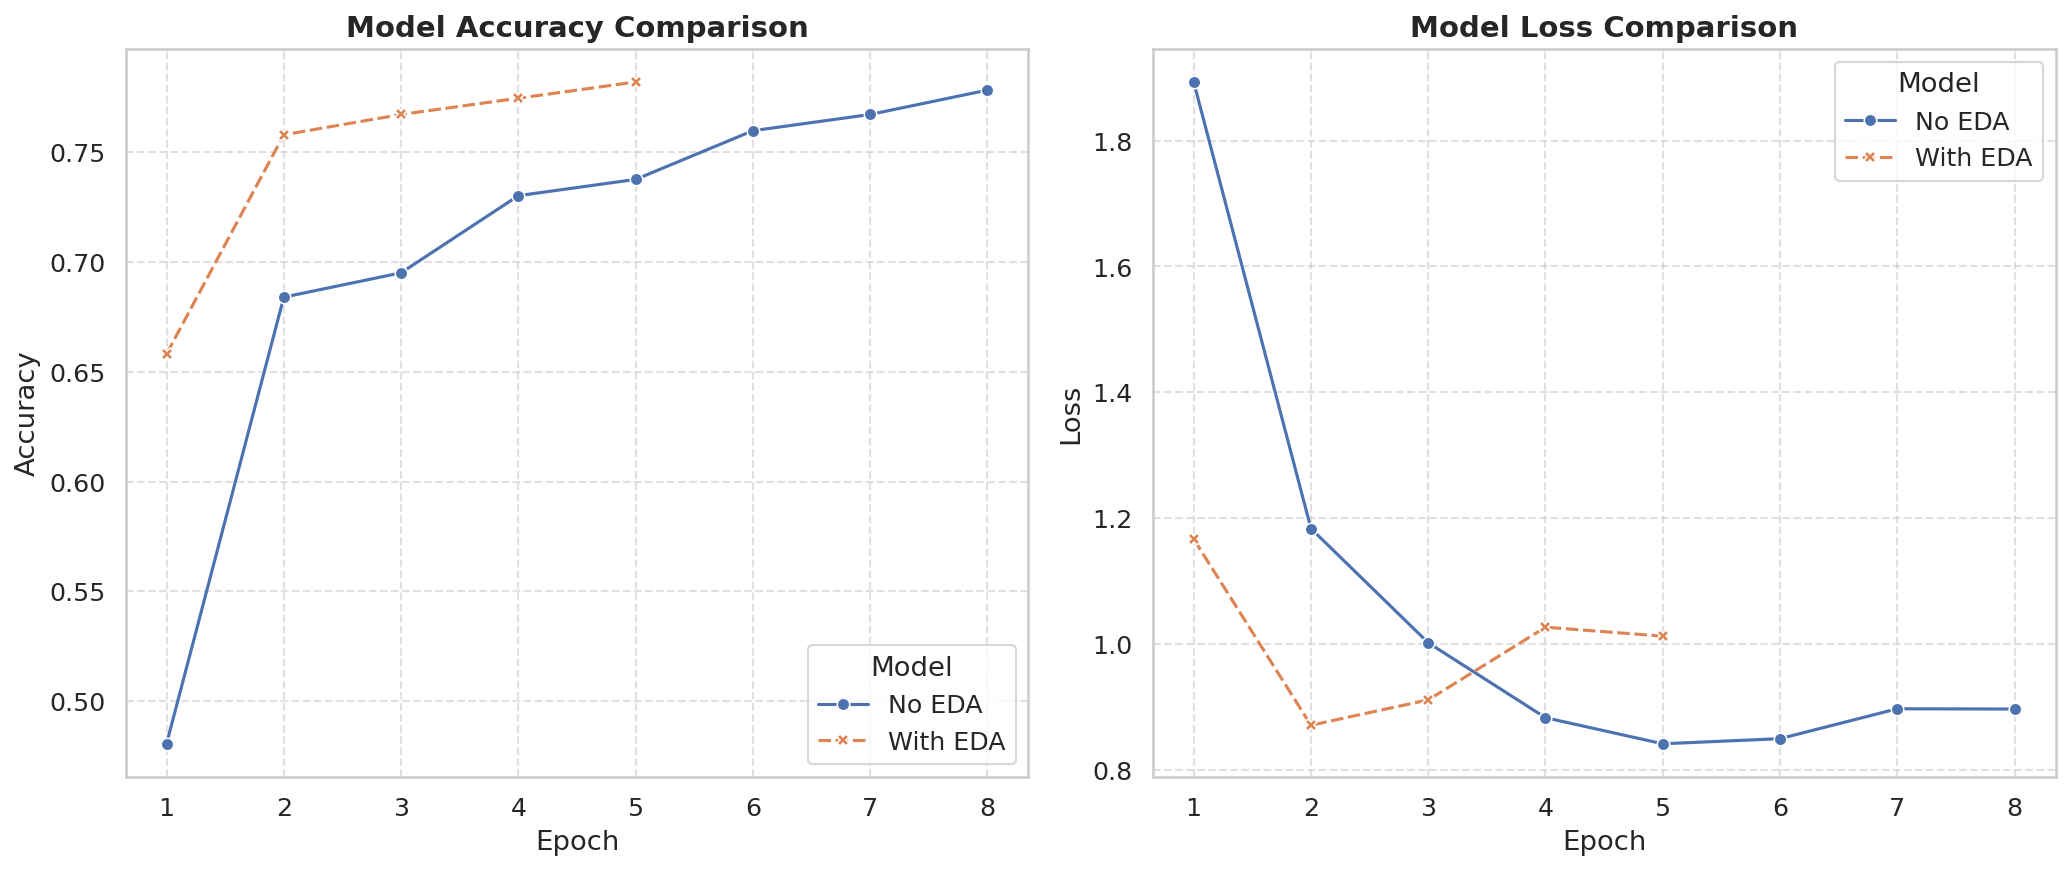

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chuyển đổi history thành DataFrame
history_orig_df = pd.DataFrame(history_orig.history)
history_orig_df['epoch'] = range(1, len(history_orig_df) + 1)
history_orig_df['model'] = 'No EDA'

history_aug_df = pd.DataFrame(history_aug.history)
history_aug_df['epoch'] = range(1, len(history_aug_df) + 1)
history_aug_df['model'] = 'With EDA'

# Gộp hai dataframe lại
combined_history = pd.concat([history_orig_df, history_aug_df], ignore_index=True)

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
# sns.lineplot(data=combined_history, x='epoch', y='accuracy', hue='model', style='model', markers=True)
sns.lineplot(data=combined_history, x='epoch', y='val_accuracy', hue='model', style='model', markers=True, linestyle='--')
plt.title('Model Accuracy Comparison', fontsize=14, weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(title='Model')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Loss ---
plt.subplot(1, 2, 2)
# sns.lineplot(data=combined_history, x='epoch', y='loss', hue='model', style='model', markers=True)
sns.lineplot(data=combined_history, x='epoch', y='val_loss', hue='model', style='model', markers=True, linestyle='--')
plt.title('Model Loss Comparison', fontsize=14, weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(title='Model')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Transformer Based Models

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Using device: cuda
Train size before/after augmentation: 4328 -> 6809
Test size: 1083

===== Training No EDA =====


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10: train_acc=0.448, val_acc=0.689
Epoch 2/10: train_acc=0.709, val_acc=0.738
Epoch 3/10: train_acc=0.757, val_acc=0.776
Epoch 4/10: train_acc=0.794, val_acc=0.760
Epoch 5/10: train_acc=0.818, val_acc=0.773
Epoch 6/10: train_acc=0.848, val_acc=0.771
Epoch 7/10: train_acc=0.871, val_acc=0.773
Epoch 8/10: train_acc=0.888, val_acc=0.773
Epoch 9/10: train_acc=0.895, val_acc=0.773
Epoch 10/10: train_acc=0.903, val_acc=0.774

===== Training With EDA =====


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10: train_acc=0.551, val_acc=0.727
Epoch 2/10: train_acc=0.782, val_acc=0.792
Epoch 3/10: train_acc=0.836, val_acc=0.830
Epoch 4/10: train_acc=0.870, val_acc=0.838
Epoch 5/10: train_acc=0.898, val_acc=0.850
Epoch 6/10: train_acc=0.917, val_acc=0.862
Epoch 7/10: train_acc=0.938, val_acc=0.867
Epoch 8/10: train_acc=0.946, val_acc=0.879
Epoch 9/10: train_acc=0.956, val_acc=0.879
Epoch 10/10: train_acc=0.962, val_acc=0.877

Results:
    Dataset  Accuracy        F1  Precision    Recall
0    No EDA  0.759003  0.758381   0.758744  0.759003
1  With EDA  0.762696  0.763058   0.764446  0.762696


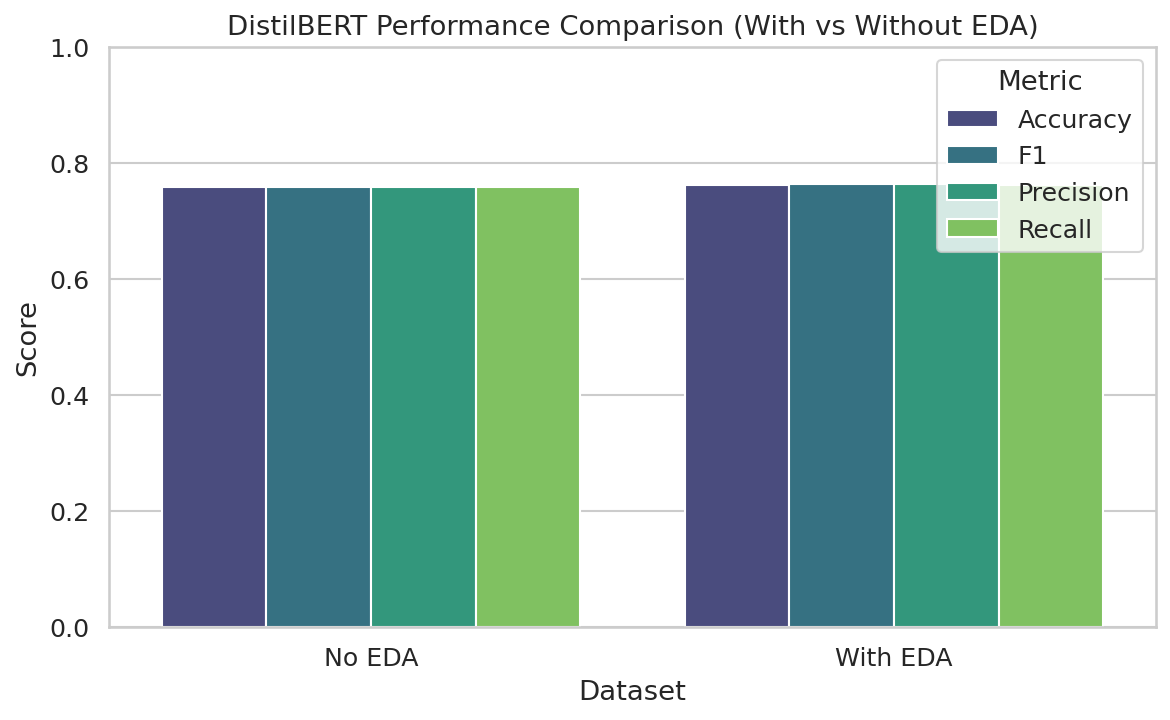

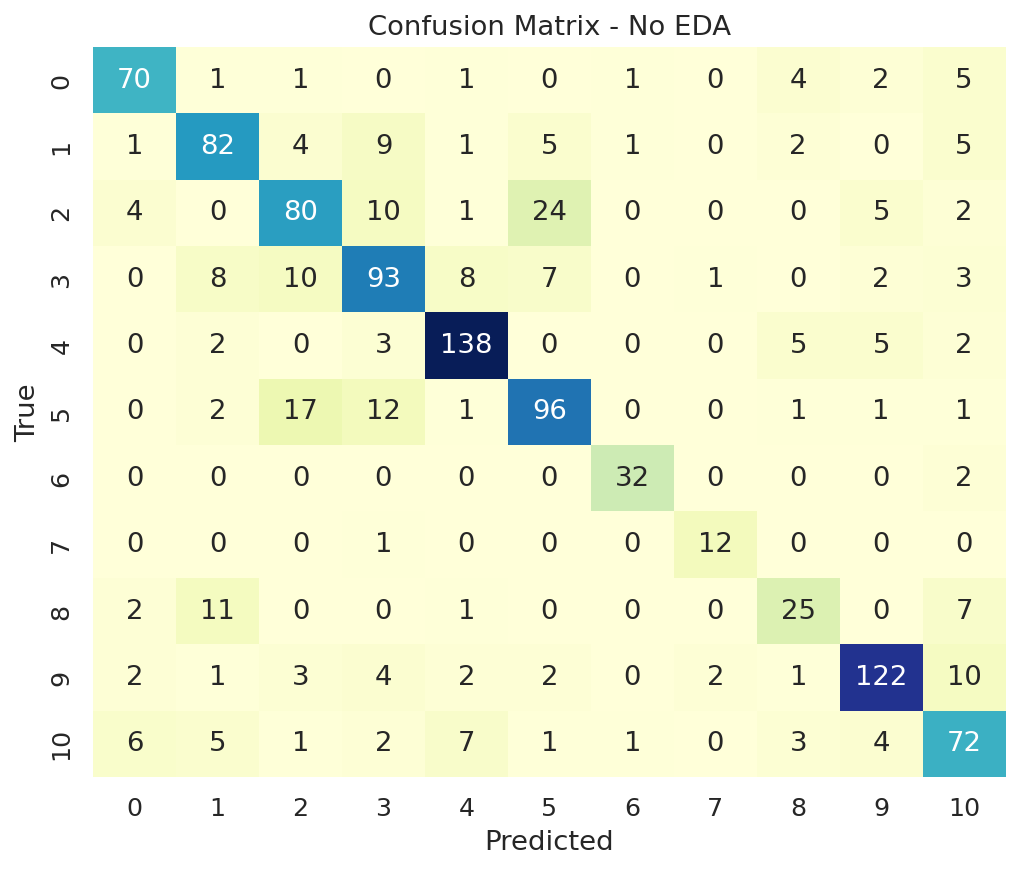

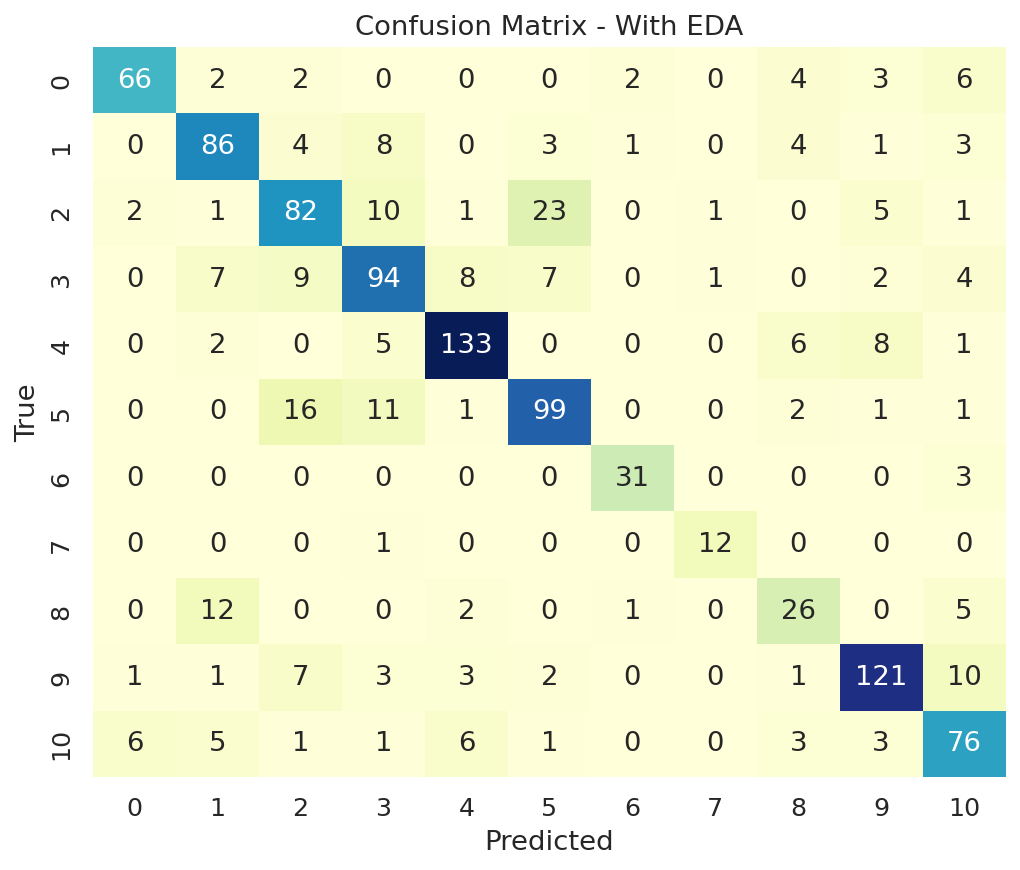


Training curves comparison:


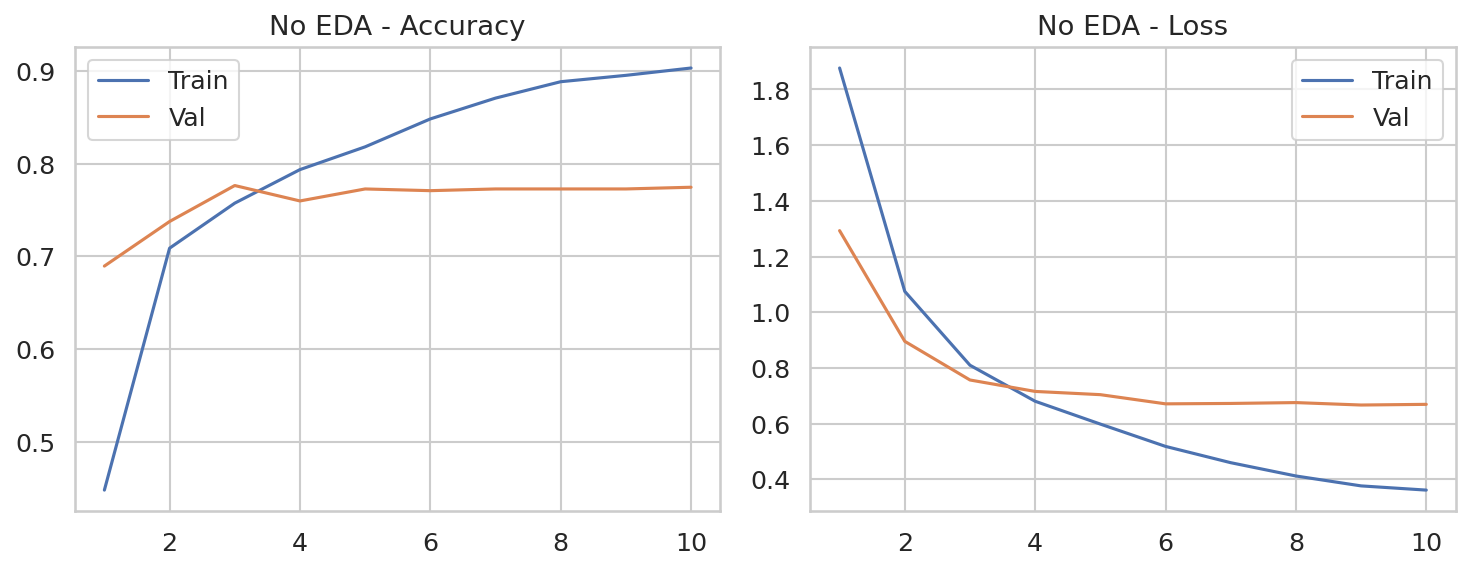

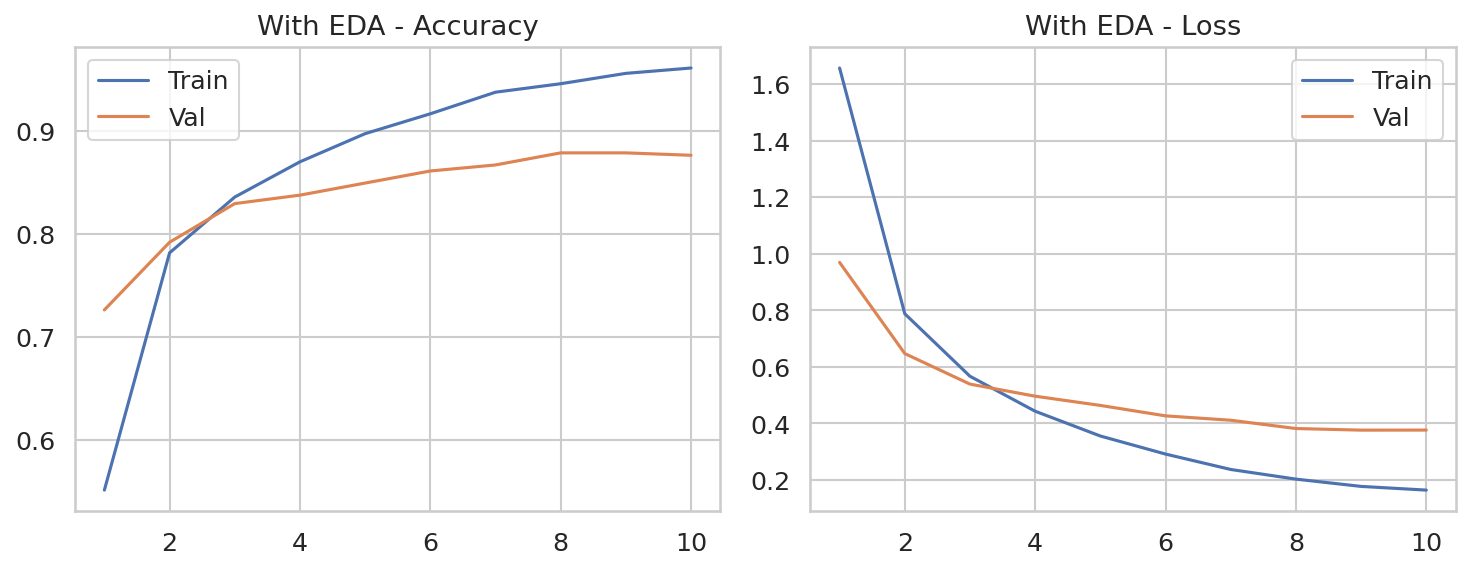

In [ ]:
import random
import nltk
from nltk.corpus import wordnet
import torch, gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')

# --------- CONFIG ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

max_len = 256
batch_size = 64
epochs = 10
random.seed(42); np.random.seed(42); torch.manual_seed(42)

# --------- EDA functions ---------
def get_synonyms(word):
    syns = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            w = lemma.name().replace('_', ' ').lower()
            if w != word.lower():
                syns.add(w)
    return list(syns)

def synonym_replacement(words, n):
    new_words = words.copy()
    indices = [i for i, w in enumerate(words) if len(get_synonyms(w))>0]
    random.shuffle(indices)
    num_replaced = 0
    for i in indices:
        synonyms = get_synonyms(words[i])
        if synonyms:
            new_words[i] = random.choice(synonyms)
            num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = [w for w in words if random.uniform(0,1) > p]
    return new_words if new_words else [random.choice(words)]

def eda_augment(sentence, alpha_sr=0.1, alpha_rs=0.1, p_rd=0.1, num_aug=2):
    words = sentence.split()
    augmented = []
    n_sr = max(1, int(alpha_sr * len(words)))
    n_rs = max(1, int(alpha_rs * len(words)))
    augmented.append(' '.join(synonym_replacement(words, n_sr)))
    augmented.append(' '.join(random_swap(words, n_rs)))
    augmented.append(' '.join(random_deletion(words, p_rd)))
    while len(augmented) < num_aug:
        augmented.append(' '.join(random_swap(words, 1)))
    return augmented[:num_aug]

def create_augmented_dataframe(df, target_col='label', text_col='clean_text', max_aug_per_sample=2):
    counts = df[target_col].value_counts()
    max_count = counts.max()
    rows = []
    for label, group in df.groupby(target_col):
        cur = group.copy()
        rows.append(cur)
        needed = max(0, max_count - len(cur))
        samples = cur[text_col].tolist()
        i = 0
        while needed > 0:
            text = samples[i % len(samples)]
            aug_texts = eda_augment(text, num_aug=min(max_aug_per_sample, needed))
            for at in aug_texts:
                rows.append(pd.DataFrame({text_col:[at], target_col:[label]}))
                needed -= 1
                if needed <= 0:
                    break
            i += 1
    return pd.concat(rows, ignore_index=True).sample(frac=1, random_state=42)

# --------- Dataset & Train/Eval ---------
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = np.array(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {"input_ids": enc['input_ids'].squeeze(), "attention_mask": enc['attention_mask'].squeeze(), "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long)}

def train_epoch(model, data_loader, optimizer, scheduler):
    model.train(); total_loss, correct, total = 0, 0, 0
    for batch in data_loader:
        input_ids, attn, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attn, labels=labels)
        loss, logits = outputs.loss, outputs.logits
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item(); preds = logits.argmax(1)
        correct += (preds == labels).sum().item(); total += labels.size(0)
    return total_loss/len(data_loader), correct/total

def eval_epoch(model, data_loader):
    model.eval(); preds_all, labels_all = [], []
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in data_loader:
            input_ids, attn, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attn, labels=labels)
            loss, logits = outputs.loss, outputs.logits
            preds = logits.argmax(1)
            total_loss += loss.item(); correct += (preds==labels).sum().item(); total += labels.size(0)
            preds_all.extend(preds.cpu().numpy()); labels_all.extend(labels.cpu().numpy())
    cm = confusion_matrix(labels_all, preds_all)
    acc = correct/total; f1 = f1_score(labels_all, preds_all, average='weighted')
    recall = recall_score(labels_all, preds_all, average='weighted'); precision = precision_score(labels_all, preds_all, average='weighted')
    return total_loss/len(data_loader), acc, f1, recall, precision, cm

if 'df' not in globals():
    raise RuntimeError('Thiếu dataframe df có cột clean_text và label.')

# --------- Split first ---------
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2,
    random_state=42, stratify=df['label']
)

train_df = pd.DataFrame({'clean_text': X_train, 'label': y_train})
test_df  = pd.DataFrame({'clean_text': X_test, 'label': y_test})

# --------- Augment training set only ---------
aug_train_df = create_augmented_dataframe(train_df)
print('Train size before/after augmentation:', len(train_df), '->', len(aug_train_df))
print('Test size:', len(test_df))

# --------- Train both ---------
results, histories, cms = [], {}, {}

for tag, dataset in [('No EDA', train_df), ('With EDA', aug_train_df)]:
    print(f"\n===== Training {tag} =====")
    X_train, X_val, y_train, y_val = train_test_split(dataset['clean_text'], dataset['label'], test_size=0.125, random_state=42, stratify=dataset['label'])
    tok = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    tr_loader = DataLoader(TextDataset(X_train,y_train,tok,max_len), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TextDataset(X_val,y_val,tok,max_len), batch_size=batch_size)
    te_loader = DataLoader(TextDataset(test_df['clean_text'], test_df['label'], tok, max_len), batch_size=batch_size)
    model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(dataset['label'].unique())).to(device)
    opt = optim.AdamW(model.parameters(), lr=2e-5)
    sched = get_linear_schedule_with_warmup(opt, 0, len(tr_loader)*epochs)
    train_accs,val_accs,train_losses,val_losses=[],[],[],[]
    for ep in range(epochs):
        tr_loss,tr_acc=train_epoch(model,tr_loader,opt,sched)
        va_loss,va_acc,f1,rec,prec,_=eval_epoch(model,va_loader)
        print(f"Epoch {ep+1}/{epochs}: train_acc={tr_acc:.3f}, val_acc={va_acc:.3f}")
        train_accs.append(tr_acc); val_accs.append(va_acc); train_losses.append(tr_loss); val_losses.append(va_loss)
    histories[tag] = {'train_acc':train_accs,'val_acc':val_accs,'train_loss':train_losses,'val_loss':val_losses}
    te_loss,te_acc,f1,rec,prec,cm=eval_epoch(model,te_loader)
    results.append({'Dataset':tag,'Accuracy':te_acc,'F1':f1,'Precision':prec,'Recall':rec})
    cms[tag]=cm
    del model; torch.cuda.empty_cache(); gc.collect()

# --------- Visualization ---------
results_df = pd.DataFrame(results)
print('\nResults:'); print(results_df)

sns.set_theme(style='whitegrid',font_scale=1.1)
plt.figure(figsize=(8,5))
res_melt = results_df.melt(id_vars='Dataset',var_name='Metric',value_name='Score')
sns.barplot(data=res_melt,x='Dataset',y='Score',hue='Metric',palette='viridis')
plt.title('DistilBERT Performance Comparison (With vs Without EDA)')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# --------- Confusion Matrix Comparison ---------
for tag, cm in cms.items():
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
    plt.title(f'Confusion Matrix - {tag}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

print('\nTraining curves comparison:')
for tag,h in histories.items():
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.lineplot(x=range(1,epochs+1),y=h['train_acc'],label='Train')
    sns.lineplot(x=range(1,epochs+1),y=h['val_acc'],label='Val')
    plt.title(f'{tag} - Accuracy')
    plt.subplot(1,2,2)
    sns.lineplot(x=range(1,epochs+1),y=h['train_loss'],label='Train')
    sns.lineplot(x=range(1,epochs+1),y=h['val_loss'],label='Val')
    plt.title(f'{tag} - Loss')
    plt.tight_layout()
    plt.show()

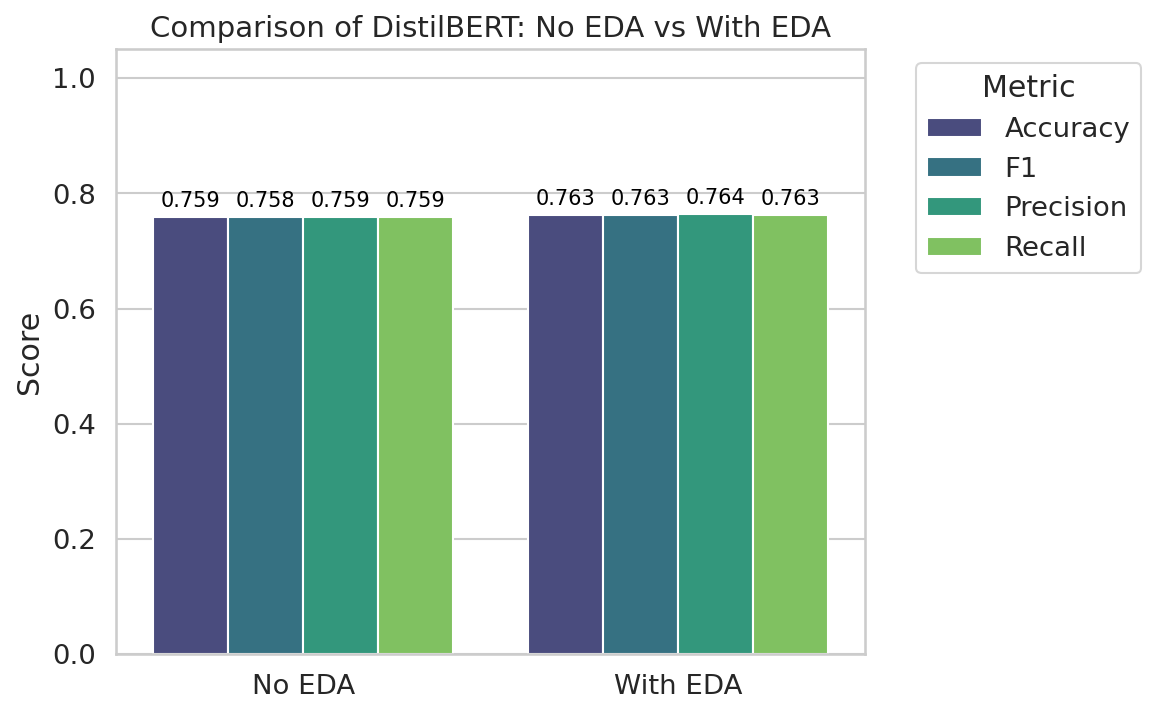

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 5))

df_melted = results_df.melt(id_vars='Dataset', var_name='Metric', value_name='Score')
ax = sns.barplot(data=df_melted, x='Dataset', y='Score', hue='Metric', palette='viridis')

# Thêm nhãn số trên mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=3, fontsize=10, color='black', rotation=0)

plt.title('Comparison of DistilBERT: No EDA vs With EDA', fontsize=14)
plt.xlabel('')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

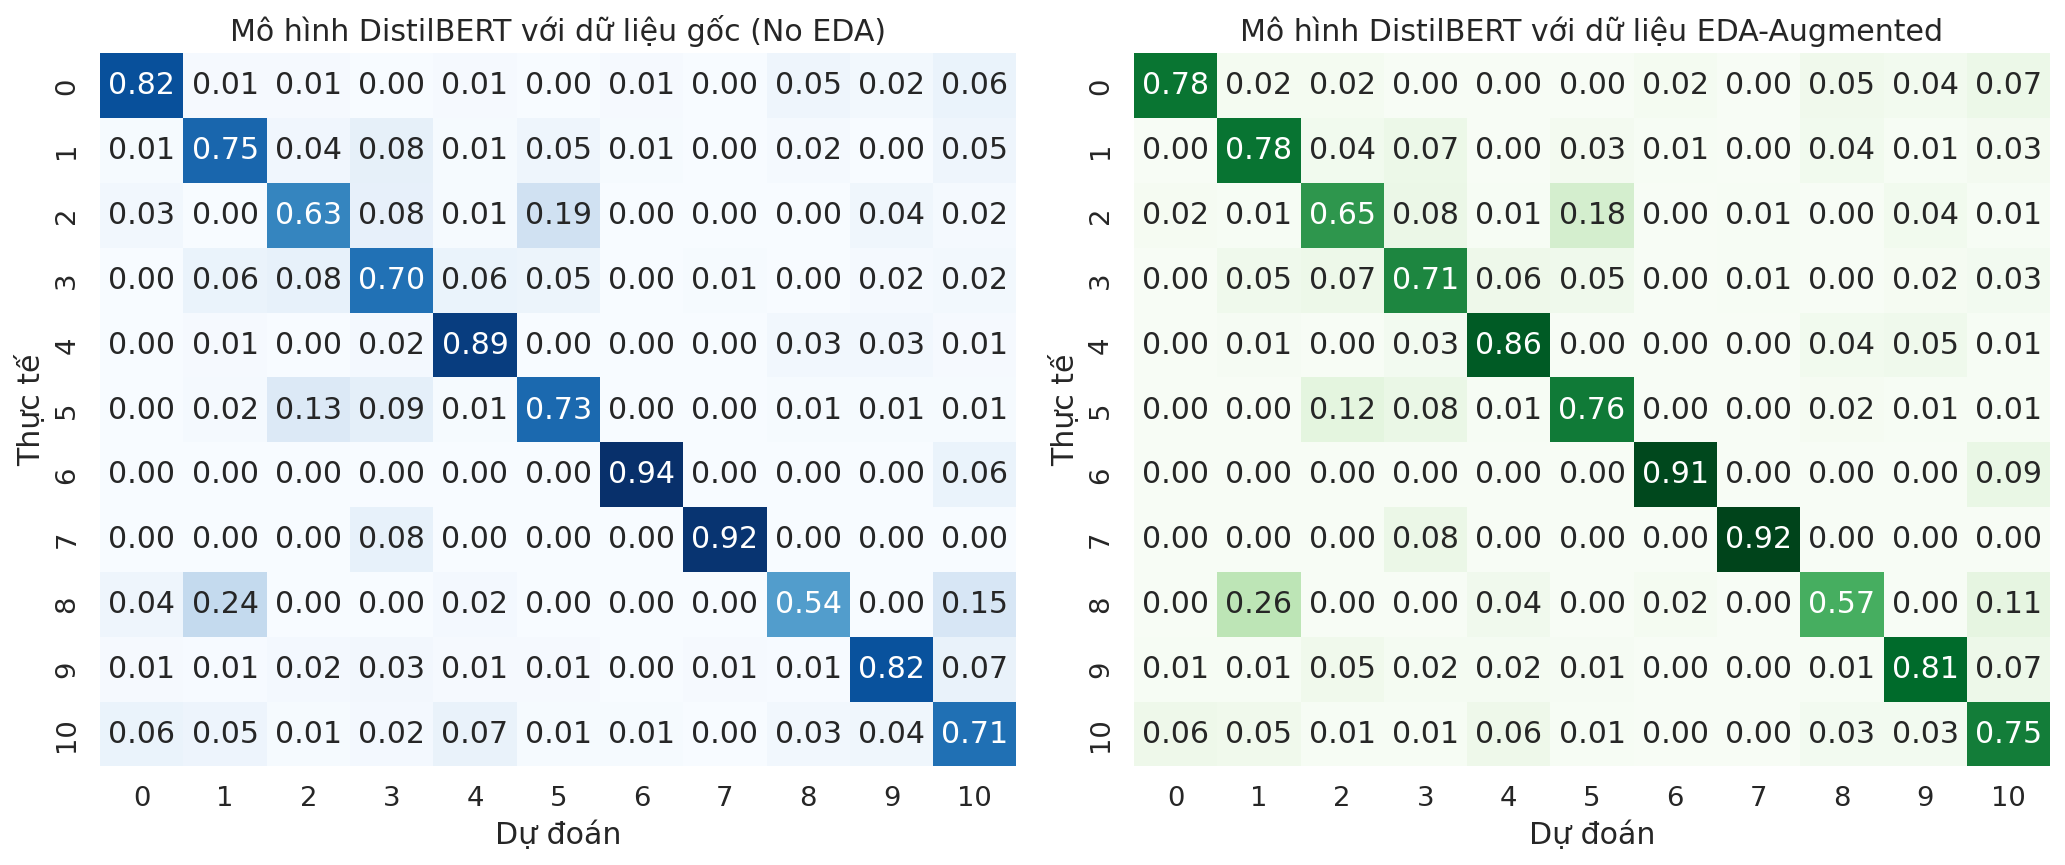

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_orig_raw = cms['No EDA']
cm_aug_raw = cms['With EDA']

cm_orig = cm_orig_raw / cm_orig_raw.sum(axis=1, keepdims=True)
cm_aug = cm_aug_raw / cm_aug_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_orig, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Mô hình DistilBERT với dữ liệu gốc (No EDA)")
axes[0].set_xlabel("Dự đoán")
axes[0].set_ylabel("Thực tế")

sns.heatmap(cm_aug, annot=True, fmt=".2f", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Mô hình DistilBERT với dữ liệu EDA-Augmented")
axes[1].set_xlabel("Dự đoán")
axes[1].set_ylabel("Thực tế")

plt.tight_layout()
plt.show()